# I. INTRODUCTION

## 1. Objectif du projet

### Analyse Statistique et Clustering - Export de Poulets

L'entreprise **La poule qui chante** souhaite développer son activité à l'international en exportant ses poulets vers de nouveaux marchés. L'objectif de cette analyse est d'**identifier des groupements de pays cibles** présentant des caractéristiques similaires favorables à l'importation de volaille française.

### Démarche analytique

1. **Explorer les données** collectées sur 170+ pays (disponibilité de volaille, population, indicateurs économiques)
2. **Analyser les relations** entre les différentes variables via une Analyse en Composantes Principales (ACP)
3. **Segmenter les pays** en groupes homogènes grâce au clustering (CAH et K-means)
4. **Identifier les marchés prioritaires** pour l'export de poulets

### Données analysées

- **Source principale :** FAO (Food and Agriculture Organization) - Données de disponibilité alimentaire 2017
- **Sources complémentaires :** Banque Mondiale - Indicateurs économiques et démographiques
- **10 variables** : Disponibilité de volaille, production, importations, population, PIB, etc.
- **~170 pays** couvrant plus de 60% de la population mondiale

## 2. Import des bibliothèques

In [1]:
# Manipulation des données
import pandas as pd
import numpy as np

# Visualisations
import matplotlib.pyplot as plt                                   # pour des graphiques et visualisations
import seaborn as sns                                             # pour des visualisations statistiques avancées
import plotly.express as px                                       # pour des graphiques interactifs

# ACP (Analyse en Composantes Principales)
from sklearn.decomposition import PCA                             # pour la réduction de dimensionnalité            
from sklearn.preprocessing import StandardScaler                  # pour la normalisation des données

# Clustering
from sklearn.cluster import AgglomerativeClustering, KMeans
from scipy.cluster.hierarchy import dendrogram, linkage           # pour le clustering hiérarchique
from scipy.spatial.distance import pdist                          # pour le calcul des distances

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')                            # applique le style visuel "seaborn" avec grille sombre aux graphiques
sns.set_palette("husl")                                           # définit la palette de couleurs "husl" (couleurs vives et distinguables)

# Afficher les graphiques directement dans le notebook
%matplotlib inline                                                

# Affichage complet des DataFrames
pd.set_option('display.max_columns', None)                        # affiche toutes les colonnes sans limite
pd.set_option('display.width', 1000)                              # définit la largeur d'affichage à 1000 caractères

print("Bibliothèques importées avec succès")

Bibliothèques importées avec succès


## 3. Chargement des données

In [4]:
# Chargement du fichier CSV préparé
import os

# Chemin vers le fichier
DATA_PATH = r"c:\Users\b303bva\Desktop\Projet_11"       # Chemin vers le dossier contenant le fichier
file_name = "df_poulet_final.csv"
chemin_complet = os.path.join(DATA_PATH, file_name)     # Chemin complet vers le fichier CSV

# Lecture du fichier
df = pd.read_csv(chemin_complet, encoding='utf-8-sig')  # Lecture du fichier CSV avec encodage UTF-8

# Informations sur le dataset
print("DATASET CHARGÉ")

print(f"\nShape : {df.shape}")
print(f"   Nombre de pays : {df.shape[0]}")             # Nombre de lignes
print(f"   Nombre de colonnes : {df.shape[1]}")         # Nombre de colonnes
print(f"   Nombre de variables : {df.shape[1] - 1}")    # Nombre de variables (en excluant la colonne 'Country')



print("\nAperçu des données :")
print(df.head())

DATASET CHARGÉ

Shape : (128, 15)
   Nombre de pays : 128
   Nombre de colonnes : 15
   Nombre de variables : 14

Aperçu des données :
          Country  Poultry imports 2017 (k tonnes)  Poultry production 2017 (k tonnes)  GDP growth avg 2000-2018 (%)  GDP per capita 2017 (US$)  Goods import 2017 (% of GDP)  Electricity acces 2017 (% of population)  Agricultural land 2017 (% of land area)  Electric power consumption 2017 (kWh per capita)  Merchandise trade 2017 (% of GDP)  Population 65+ 2017 (% of total)  Population density 2017 (per sq. km)  Urban population 2017 (% of total)  Population 15-64 2017 (% of total)  Undernourishment 2017 (% of population)
0  Afrique du Sud                            514.0                              1667.0                          2.80                    6618.34                         26.20                                      84.4                                    79.42                                           3939.82                              49

# II. ANALYSE UNIVARIÉE

* Objectif : comprendre chaque variable individuellement. 
* Pour CHAQUE variable : 
    * Distribution (histogramme/boxplot), 
    * Statistiques descriptives
    * Détection des outliers


 VARIABLE : Poultry imports 2017 (k tonnes)

Statistiques :
count     128.00
mean      106.01
std       197.15
min         0.00
25%         3.00
50%        24.00
75%       110.00
max      1069.00
Name: Poultry imports 2017 (k tonnes), dtype: float64


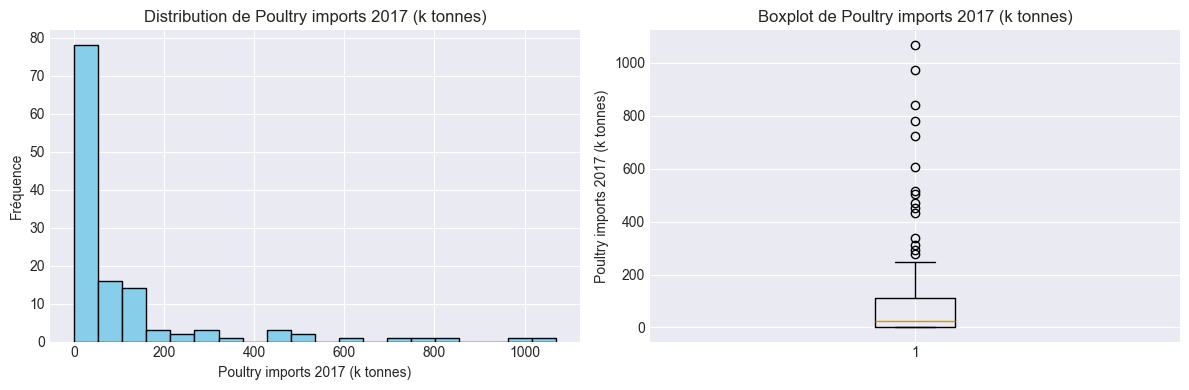




 VARIABLE : Poultry production 2017 (k tonnes)

Statistiques :
count      128.00
mean       917.24
std       2835.81
min          0.00
25%         41.50
50%        114.00
75%        649.75
max      21914.00
Name: Poultry production 2017 (k tonnes), dtype: float64


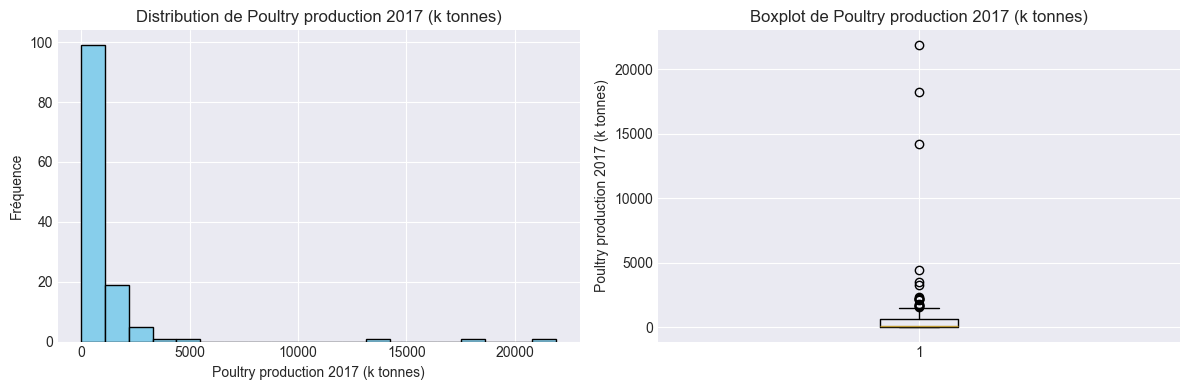




 VARIABLE : GDP growth avg 2000-2018 (%)

Statistiques :
count    128.00
mean       3.93
std        1.89
min        0.08
25%        2.62
50%        3.90
75%        4.97
max        9.17
Name: GDP growth avg 2000-2018 (%), dtype: float64


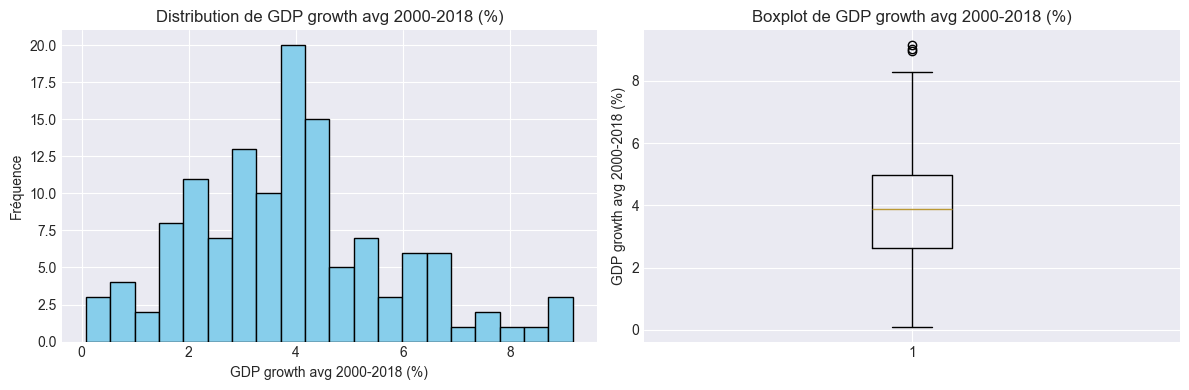




 VARIABLE : GDP per capita 2017 (US$)

Statistiques :
count       128.00
mean      15692.22
std       20320.89
min         470.94
25%        2562.53
50%        6513.78
75%       19601.37
max      110193.21
Name: GDP per capita 2017 (US$), dtype: float64


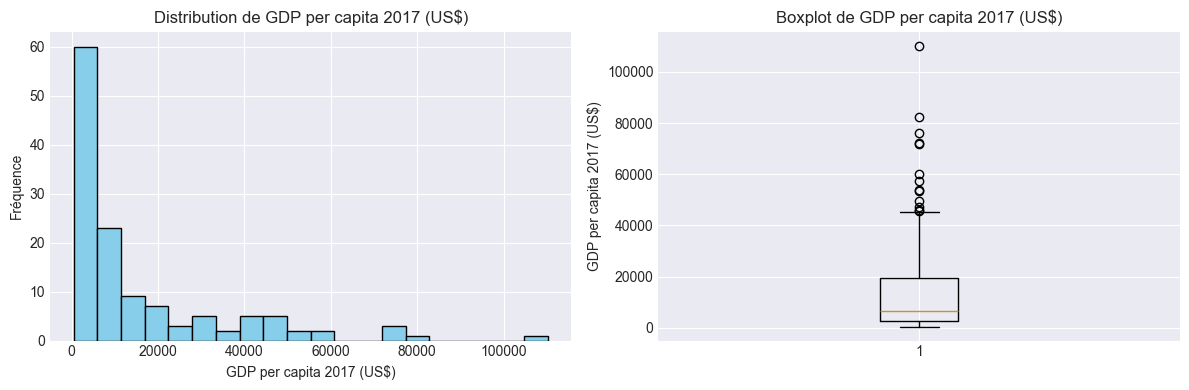




 VARIABLE : Goods import 2017 (% of GDP)

Statistiques :
count    128.00
mean      41.95
std       22.10
min       11.67
25%       26.50
50%       36.39
75%       54.72
max      161.05
Name: Goods import 2017 (% of GDP), dtype: float64


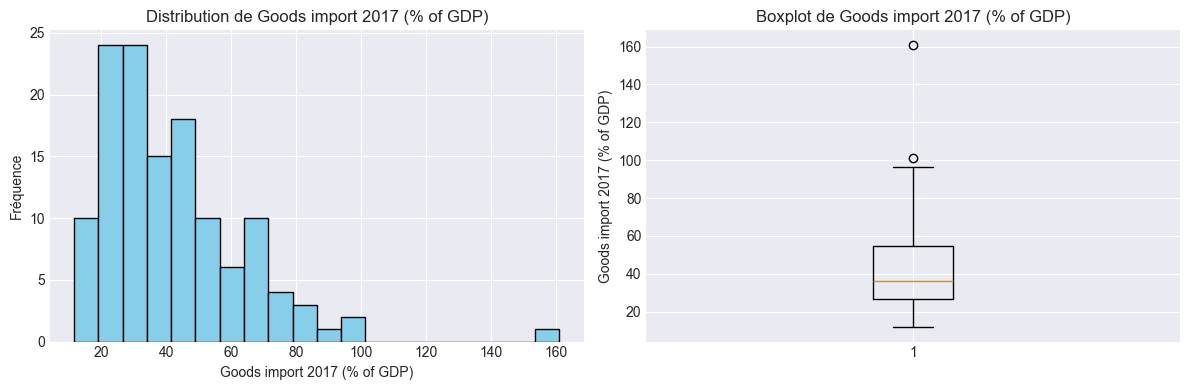




 VARIABLE : Electricity acces 2017 (% of population)

Statistiques :
count    128.00
mean      87.38
std       23.18
min       10.90
25%       87.65
50%       99.95
75%      100.00
max      100.00
Name: Electricity acces 2017 (% of population), dtype: float64


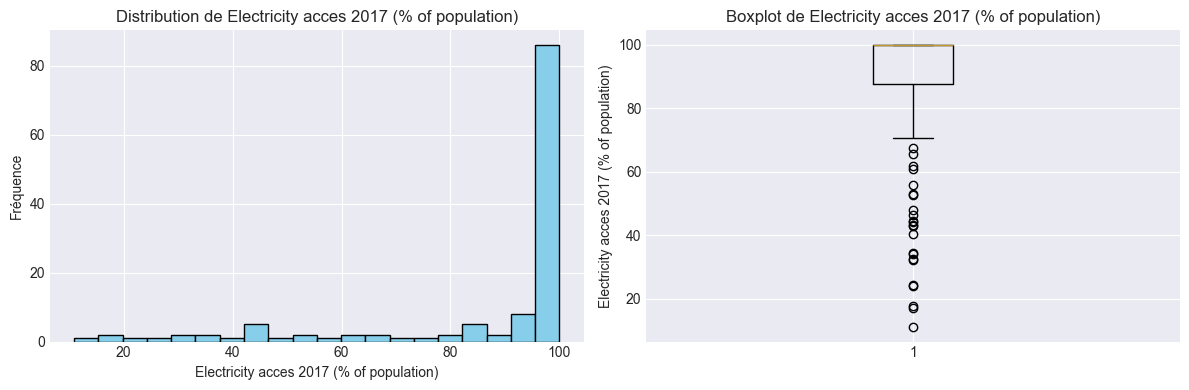




 VARIABLE : Agricultural land 2017 (% of land area)

Statistiques :
count    128.00
mean      42.32
std       19.78
min        2.70
25%       29.75
50%       43.02
75%       53.44
max       81.42
Name: Agricultural land 2017 (% of land area), dtype: float64


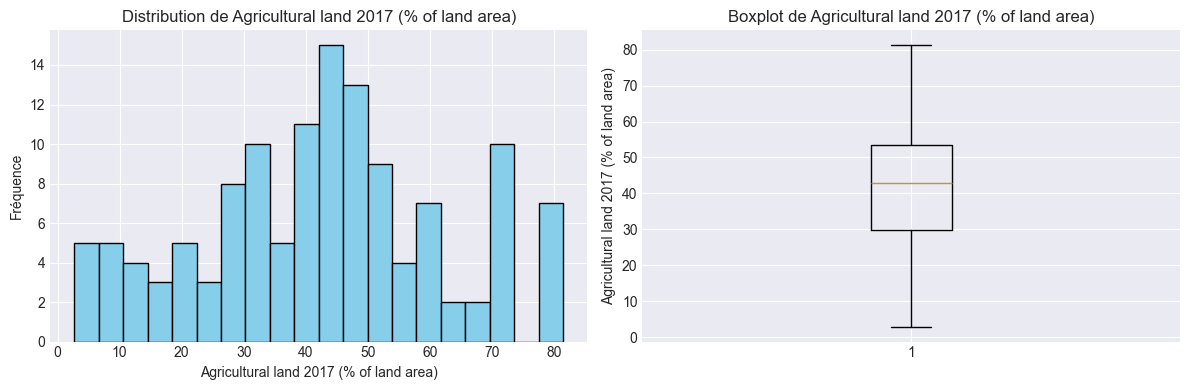




 VARIABLE : Electric power consumption 2017 (kWh per capita)

Statistiques :
count      128.00
mean      4157.67
std       6056.82
min         13.31
25%        790.40
50%       2293.55
75%       5283.39
max      54301.11
Name: Electric power consumption 2017 (kWh per capita), dtype: float64


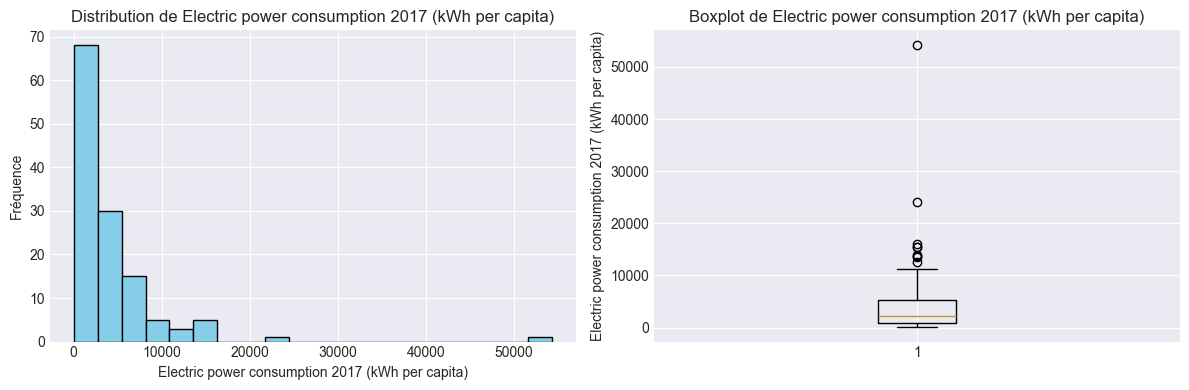




 VARIABLE : Merchandise trade 2017 (% of GDP)

Statistiques :
count    128.00
mean      61.95
std       35.01
min       12.20
25%       37.54
50%       52.18
75%       76.31
max      171.95
Name: Merchandise trade 2017 (% of GDP), dtype: float64


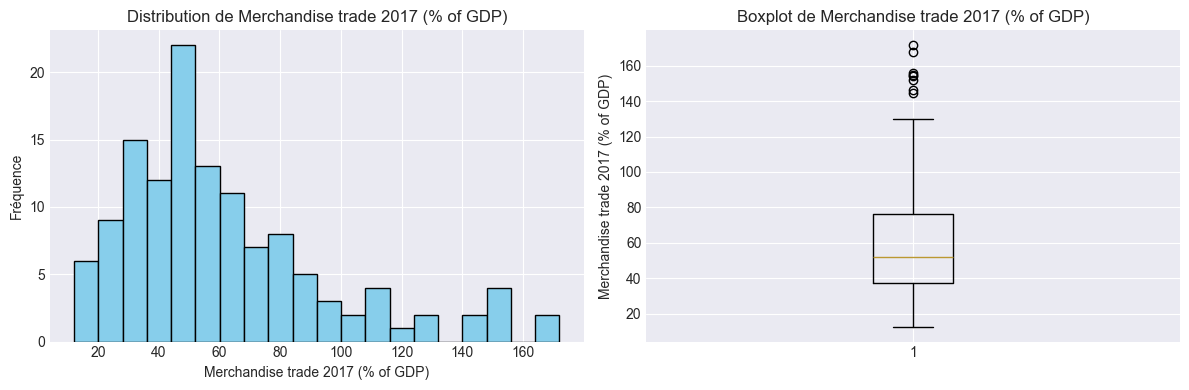




 VARIABLE : Population 65+ 2017 (% of total)

Statistiques :
count    128.00
mean       9.93
std        6.68
min        1.48
25%        3.64
50%        7.37
75%       15.28
max       27.98
Name: Population 65+ 2017 (% of total), dtype: float64


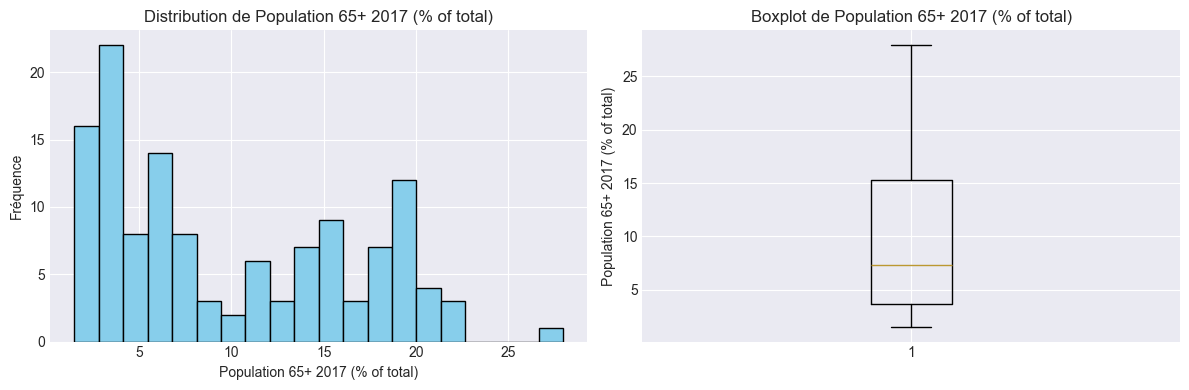




 VARIABLE : Population density 2017 (per sq. km)

Statistiques :
count     128.00
mean      134.88
std       197.88
min         2.02
25%        31.11
50%        80.33
75%       137.74
max      1459.71
Name: Population density 2017 (per sq. km), dtype: float64


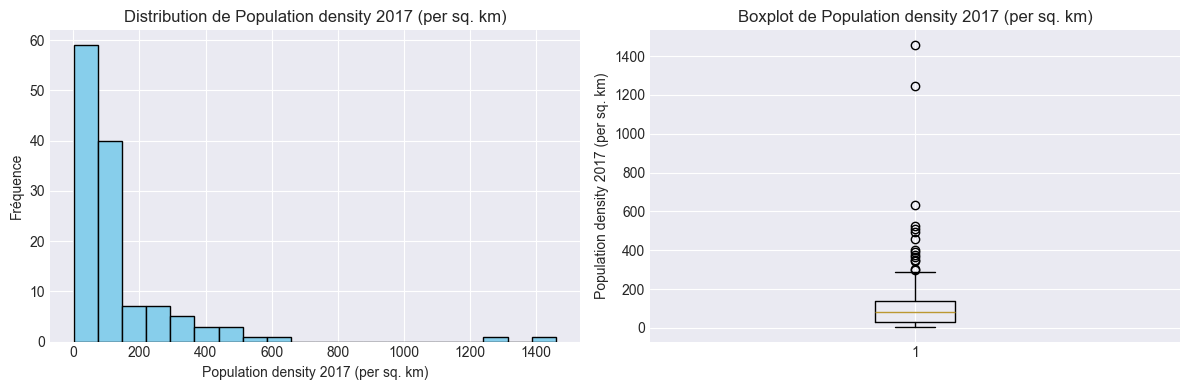




 VARIABLE : Urban population 2017 (% of total)

Statistiques :
count    128.00
mean      62.23
std       21.10
min       16.35
25%       48.72
50%       65.34
75%       79.83
max      100.00
Name: Urban population 2017 (% of total), dtype: float64


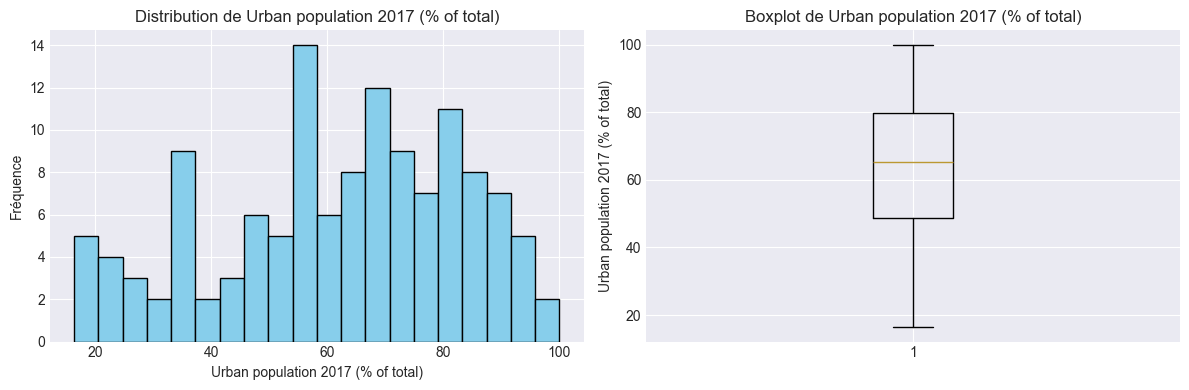




 VARIABLE : Population 15-64 2017 (% of total)

Statistiques :
count    128.00
mean      63.92
std        5.75
min       48.71
25%       62.00
50%       65.09
75%       67.31
max       81.76
Name: Population 15-64 2017 (% of total), dtype: float64


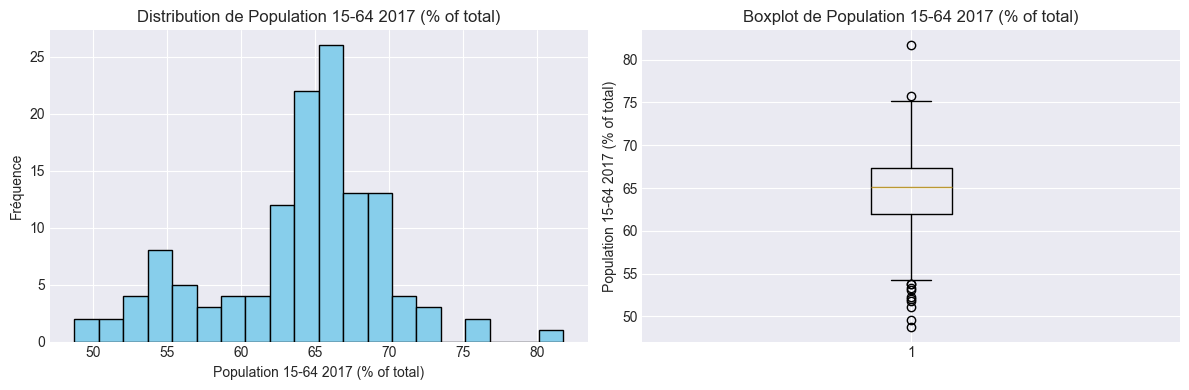




 VARIABLE : Undernourishment 2017 (% of population)

Statistiques :
count    128.00
mean       8.39
std        9.45
min        2.50
25%        2.50
50%        3.90
75%       10.50
max       42.00
Name: Undernourishment 2017 (% of population), dtype: float64


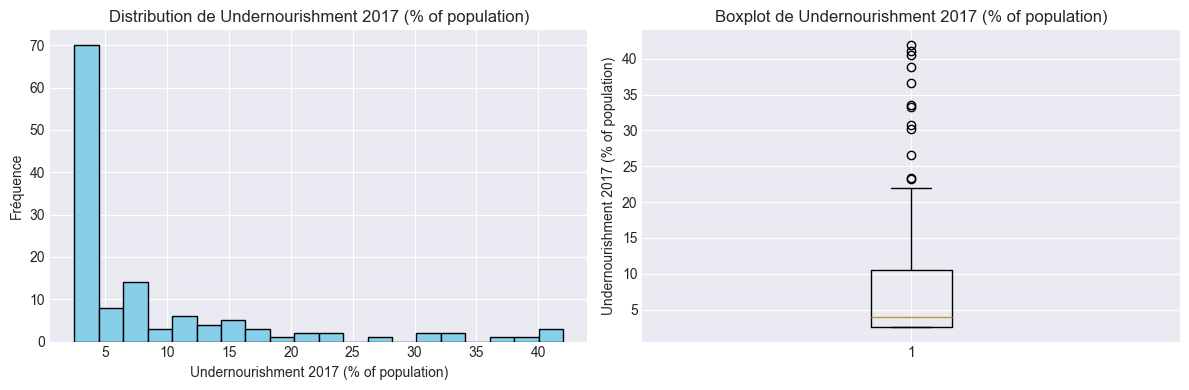

In [7]:
# Sélection des variables numériques (sans la colonne 'Country')
variables = df.select_dtypes(include=[np.number]).columns.tolist()     # Liste des variables numériques (excluant les variables non numériques)

# Analyse de chaque variable
for var in variables:
    print("\n" + "="*70)                                               # Séparateur visuel 
    print(f" VARIABLE : {var}")
    print("="*70)
    
    # Statistiques descriptives
    print("\nStatistiques :")
    print(df[var].describe().round(2))                                 # Affichage des statistiques descriptives arrondies à 2 décimales
    
    # Graphiques : histogramme + boxplot
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))                    # Création d'une figure avec 2 sous-graphiques et une taille de 12x4 pouces             
    
    # Histogramme
    axes[0].hist(df[var], bins=20, color='skyblue', edgecolor='black')  # Histogramme avec 20 bacs et bordures noires
    axes[0].set_title(f'Distribution de {var}')                         # Titre de l'histogramme avec la variable
    axes[0].set_xlabel(var)                                             # Label de l'axe x avec la variable
    axes[0].set_ylabel('Fréquence')                                     # Label de l'axe y 'Fréquence' 
    
    # Boxplot
    axes[1].boxplot(df[var])                                            # Boxplot de la variable avec bordures noires
    axes[1].set_title(f'Boxplot de {var}')                              # Titre du boxplot avec la variable
    axes[1].set_xlabel('')                                              # Label de l'axe x vide
    axes[1].set_ylabel(var)                                             # Label de l'axe y avec la variable
    
    plt.tight_layout()                                                  # Ajustement de la mise en page
    plt.show()                                                          # Afficher les graphiques
    
    print("\n")

### Interprétation de l'analyse univariée

**Poultry availability 2017** - Disponibilité de viande de volaille par personne par an. La médiane de 17 kg montre qu'un marché typique consomme une quantité moyenne. La moyenne de 18,87 kg est un peu plus élevée que la médiane à cause des pays avec une très forte consommation. Le maximum de 67 kg montre l'existence de marchés développés avec une culture forte de consommation de volaille. La distribution est asymétrique avec une longue queue à droite, ce qui montre trois groupes de marchés : faible consommation (0-10 kg), moyenne (10-30 kg) et forte (30+ kg). Pour l'export, les marchés moyens avec un potentiel de croissance et les marchés forts avec de gros volumes sont intéressants.

**Poultry imports 2017** - Volume d'importation de volaille en milliers de tonnes. La distribution est très inégale avec une médiane de seulement 17 mille tonnes et une moyenne de 93, ce qui montre que la plupart des pays importent peu, mais il y a de gros importateurs qui font monter la moyenne. L'écart-type de 185 est plus grand que la moyenne, ce qui montre un très grand écart entre les pays. Le maximum de 1069 mille tonnes représente un million de tonnes d'importation. L'histogramme montre que la majorité des pays sont dans la plage 0-200 mille tonnes, et seulement quelques-uns sont de gros importateurs. Les nombreux outliers sur le boxplot confirment la diversité des marchés d'importation. Pour l'export, il est critique d'identifier ces gros pays importateurs comme cibles prioritaires.

**Poultry production 2017** - Volume de production intérieure de volaille. La médiane de 81 mille tonnes et la moyenne de 794 mille montrent une très grande asymétrie à cause de quelques pays géants producteurs. Le maximum de 21914 mille tonnes (environ 22 millions de tonnes) indique les USA, la Chine ou le Brésil. La majorité des pays sont de petits producteurs avec moins de 500 mille tonnes, mais quelques gros acteurs produisent beaucoup plus. Les pays avec une faible production mais une forte consommation sont des marchés d'importation idéaux, tandis que les pays avec une énorme production sont plutôt des concurrents que des clients.

**Population total 2017** - Population totale en millions. La médiane de 10,5 millions et la moyenne de 46,72 montrent que la moitié des pays sont petits, mais il y a des géants démographiques qui font monter la moyenne. Le maximum de 1421 millions représente la Chine ou l'Inde. La distribution est très asymétrique avec la majorité des pays en dessous de 50 millions d'habitants et seulement quelques très grands marchés au-dessus de 100 millions. La taille de la population détermine directement le volume potentiel du marché, mais il faut regarder aussi la consommation par personne et le pouvoir d'achat.

**Population growth 2017-2018** - Taux de croissance annuel de la population en pourcentage. La médiane de 1,17% et la moyenne de 1,24% montrent une distribution assez symétrique proche de la normale avec un centre autour de 1%. Il y a des pays avec une baisse de population jusqu'à -1,55% (pays européens développés avec vieillissement de la population). Les marchés à croissance rapide jusqu'à 3,89% sont des pays africains avec forte natalité. Une croissance modérée de 1-2% est typique des pays en développement d'Asie et d'Amérique Latine. Une population qui grandit rapidement signifie une demande croissante en nourriture incluant la viande de volaille, ce qui rend ces marchés intéressants à long terme.

**GDP growth avg 2000-2018** - Taux moyen de croissance du PIB sur 18 ans. La médiane de 3,79% et la moyenne de 3,83% montrent une distribution assez symétrique et compacte. La plage de presque zéro à 9% par an montre la différence entre les économies développées stagnantes et les économies en développement à croissance rapide. La majorité des pays sont dans la plage 2-5% de croissance annuelle, ce qui est considéré comme une bonne dynamique économique. Les pays avec une croissance du PIB stable de 3%+ montrent une hausse des revenus de la population et donc une hausse de la consommation de produits protéinés incluant la volaille. C'est un indicateur à long terme de la santé économique et du potentiel du marché.

**GDP per capita 2017** - PIB par habitant en dollars américains. La médiane de 5828 dollars et la moyenne de 14413 dollars montrent une grande asymétrie et inégalité entre les pays. Le maximum de 110193 dollars représente les riches pays pétroliers comme le Qatar ou les pays développés comme la Suisse. La majorité des pays sont dans la plage 2000-20000 dollars (pays pauvres et moyennement développés). L'histogramme montre une concentration dans le segment pauvre et une longue queue de pays riches outliers. Le PIB par habitant est très important pour déterminer le pouvoir d'achat et la capacité à payer pour des produits importés de qualité. Les pays avec un revenu moyen de 5000-15000 dollars montrent souvent la croissance la plus rapide de consommation de viande lors du passage de la pauvreté à la classe moyenne.

**Goods import 2017** - Part des importations de biens dans le PIB en pourcentage. La médiane de 37,77% et la moyenne de 42,83% montrent une distribution assez symétrique avec un petit décalage à droite. La plage de 11,67 à 161,05% montre une énorme différence entre les grandes économies relativement fermées avec une forte production intérieure et les petites économies ouvertes qui dépendent beaucoup des importations. Les valeurs au-dessus de 100% sont possibles pour les centres de ré-exportation comme Singapour ou Hong Kong. Une part élevée d'importation de 50%+ indique une ouverture du marché aux fournisseurs étrangers et une infrastructure d'importation développée, ce qui facilite l'entrée sur ce marché.

**Electricity access 2017** - Accès de la population à l'électricité en pourcentage. La médiane de presque 100% et la moyenne de 84,54% montrent une distribution bimodale avec deux groupes bien marqués. Le premier groupe est les pays développés avec un accès complet à 100%, visible par la grande colonne à droite sur l'histogramme. Le deuxième groupe est les pays en développement avec un faible accès de 10 à 80% (pays africains avec infrastructure peu développée). Le boxplot montre beaucoup d'outliers en bas (pays avec faible électrification). L'accès à l'électricité est critique pour les chaînes du froid de stockage et transport de viande de volaille fraîche. Les pays avec faible électrification nécessitent des formats de livraison alternatifs comme les produits congelés ou en conserve.

# III. ANALYSE BIVARIÉE

* Objectif: Identifier les relations entre variables. 
* Corrélations entre TOUTES les variables 2 à 2: 
    * Matrice de corrélation (heatmap)
    * Tests de corrélation (Pearson)
    * Scatter plots pour les corrélations fortes

### Matrice de corrélation (heatmap)

La matrice montre les corrélations entre toutes les paires de variables simultanément. Chaque cellule = corrélation entre deux variables. Les avantages d'une telle analyse sont les suivants : on voit tout le tableau d'un seul coup d'œil, il est facile de trouver les liens les plus forts par couleur, c'est la norme en analyse statistique. La taille du graphique est suffisamment grande pour que les 14 variables soient lisibles. 

Matrice de corrélation créée avec succès (méthode Spearman)
   - Forme : (14, 14)) 
   - Nombre total de cases : 196
   - Nombre de paires uniques : 91

                                                  Poultry imports 2017 (k tonnes)  Poultry production 2017 (k tonnes)  GDP growth avg 2000-2018 (%)  GDP per capita 2017 (US$)  Goods import 2017 (% of GDP)  Electricity acces 2017 (% of population)  Agricultural land 2017 (% of land area)  Electric power consumption 2017 (kWh per capita)  Merchandise trade 2017 (% of GDP)  Population 65+ 2017 (% of total)  Population density 2017 (per sq. km)  Urban population 2017 (% of total)  Population 15-64 2017 (% of total)  Undernourishment 2017 (% of population)
Poultry imports 2017 (k tonnes)                                              1.00                                0.27                         -0.26                       0.39                          0.18                                      0.40                                    -0.02  

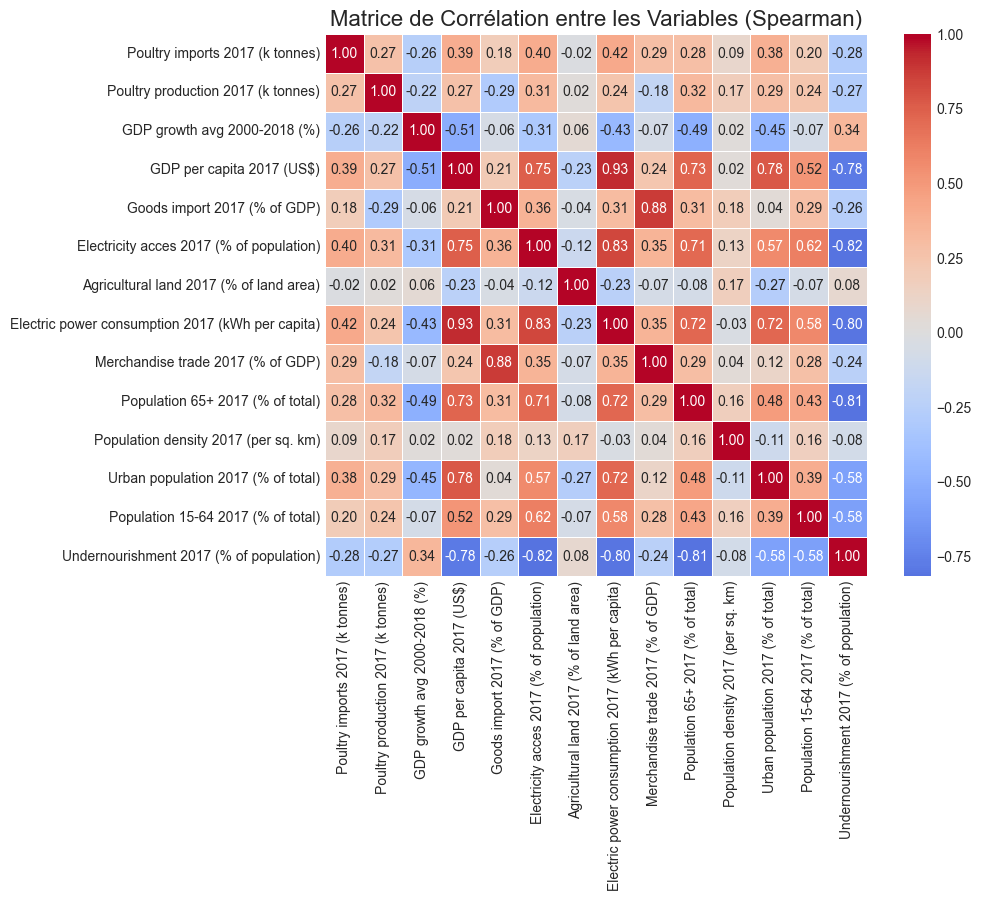

In [13]:
# ÉTAPE 1 : Sélectionner UNIQUEMENT les colonnes numériques
# La corrélation ne peut être calculée QUE sur des chiffres (pas sur du texte)
# On doit donc ÉLIMINER la colonne 'Country' avant le calcul
# select_dtypes() = fonction qui FILTRE les colonnes par type de données
# include=[np.number] = garder SEULEMENT les colonnes de type "nombre"

df_numeric = df.select_dtypes(include=[np.number])

# ÉTAPE 2 : Calculer la matrice de corrélation avec méthode de SPEARMAN
# C'est un tableau carré (13×13) qui contient TOUTES les corrélations possibles
# La DIAGONALE toujours = 1.00 (une variable corrèle parfaitement avec elle-même)

# .corr(method='spearman') = méthode pandas qui calcule les corrélations avec Spearman
#   - PEARSON mesure seulement les relations LINÉAIRES
#   - SPEARMAN mesure les relations MONOTONES (linéaires ET non-linéaires)
#   - SPEARMAN est PLUS ROBUSTE aux outliers et distributions non-normales

# Fonctionnement de Spearman :
#   1. Convertir chaque variable en RANGS (1er, 2ème, 3ème...)
#   2. Calculer la corrélation de Pearson sur les RANGS
#   3. Résultat entre -1 et +1 indiquant la force et la direction de la relation monotone

correlation_matrix = df_numeric.corr(method='spearman')

print("Matrice de corrélation créée avec succès (méthode Spearman)")
print(f"   - Forme : {correlation_matrix.shape}) ")
print(f"   - Nombre total de cases : {correlation_matrix.shape[0] * correlation_matrix.shape[1]}")
print(f"   - Nombre de paires uniques : {(correlation_matrix.shape[0] * (correlation_matrix.shape[0]-1)) // 2}\n")

# AFFICHAGE : Tableau textuel avec les valeurs des corrélations
print(correlation_matrix.round(2))                                    # Affiche la matrice avec 2 décimales

# Visualisation : Heatmap de la matrice de corrélation
plt.figure(figsize=(11, 9))                                           # Crée une grande figure de 12x10 pouces
sns.heatmap(correlation_matrix,                                       # Dessine la heatmap avec la matrice de corrélation
            annot=True,                                               # Affiche les valeurs dans chaque case
            cmap='coolwarm',                                          # Palette de couleurs : bleu (négatif) à rouge (positif)
            center=0,                                                 # Centre la palette sur 0
            fmt='.2f',                                                # Format des nombres : 2 décimales
            square=True,                                              # Cases carrées
            linewidths=0.5)                                           # Lignes de séparation entre les cases
plt.title('Matrice de Corrélation entre les Variables (Spearman)', fontsize=16) # Titre du graphique
plt.tight_layout()                                                    # Ajuste la mise en page
plt.show()                                                            # Affiche le graphique

**Corrélations positives les plus fortes :**

* PIB par habitant ↔ Accès à l'électricité (0.80) : Les pays riches ont une électrification presque totale, essentielle pour les chaînes du froid.
* Production de volaille ↔ Population totale (0.77) : Les pays très peuplés produisent naturellement plus de volaille pour nourrir leur population.

**Corrélations négatives les plus fortes :**

* Croissance démographique ↔ Accès à l'électricité (-0.66) : Les pays à forte natalité ont souvent une infrastructure électrique limitée.
* Croissance démographique ↔ PIB par habitant (-0.59) : Les pays pauvres ont une forte croissance démographique, tandis que les pays riches stagnent.

### 2. Scatter plots interactifs pour TOP-5 correlations (avec noms des pays)

Le nuage de points permet de détecter visuellement :

* Si la relation est vraiment linéaire ou s'il s'agit d'une parabole/exponentielle
* S'il existe des valeurs aberrantes influentes qui faussent la corrélation
* S'il existe des sous-groupes avec des modèles différents
* La présence d'effets de seuil (par exemple : électricité <50 % = pas de consommation)


In [14]:
# Extraire toutes les paires de variables de la matrice
nombre_variables = len(correlation_matrix.columns)  # Nombre total de variables dans notre analyse
correlations_list = [] # Créer une liste vide pour stocker toutes les paires de corrélations

# DOUBLE BOUCLE pour parcourir toutes les combinaisons possibles
# Première boucle : variable i va de 0 à 13 (pour 14 variables)
for i in range(nombre_variables):
    
    # Deuxième boucle : variable j commence à i+1 pour éviter les doublons
    # Si i=0 (Poultry availability), j commence à 1 (Poultry imports, Production, etc.)
    # Si i=1 (Poultry imports), j commence à 2 (Production, Population, etc.)
    
    for j in range(i+1, nombre_variables):              
        var1 = correlation_matrix.columns[i] # Récupérer le NOM de la première variable (ex: "Poultry availability 2017")
        var2 = correlation_matrix.columns[j] # Récupérer le NOM de la deuxième variable (ex: "Poultry imports 2017")
        
        # Récupérer la VALEUR de corrélation entre ces deux variables
        corr_value = correlation_matrix.iloc[i, j]  # iloc[i, j] = accès à la case ligne i, colonne j de la matrice
        
        # Ajouter cette paire à liste sous forme de dictionnaire
        correlations_list.append({
            'Variable 1': var1,                  # Première variable du couple
            'Variable 2': var2,                  # Deuxième variable du couple
            'Corrélation': round(corr_value, 3)  # Valeur arrondie à 3 décimales
        })

# Créer un tableau (DataFrame) avec toutes les corrélations
df_correlations = pd.DataFrame(correlations_list)

# Ajouter une colonne avec la valeur ABSOLUE de corrélation
# trier par FORCE de la relation (peu importe le signe)
df_correlations['Abs_Correlation'] = df_correlations['Corrélation'].abs()

# Trier les paires par force de corrélation (du plus fort au plus faible)
# ascending=False signifie ordre décroissant (les plus grandes valeurs en premier)
df_correlations = df_correlations.sort_values('Abs_Correlation', ascending=False)

# Sélectionner les 5 paires les plus fortes
# .head(5) = prendre les 5 premières lignes après le tri
# .drop('Abs_Correlation', axis=1) = supprimer la colonne temporaire 'Abs_Correlation'
top_correlations = df_correlations.head(5).drop('Abs_Correlation', axis=1)

# Afficher le résultat final : TOP 5 des corrélations les plus fortes
print(top_correlations.to_string(index=False))  # index=False pour ne pas afficher les numéros de lignes

                              Variable 1                                       Variable 2  Corrélation
               GDP per capita 2017 (US$) Electric power consumption 2017 (kWh per capita)        0.926
            Goods import 2017 (% of GDP)                Merchandise trade 2017 (% of GDP)        0.875
Electricity acces 2017 (% of population) Electric power consumption 2017 (kWh per capita)        0.833
Electricity acces 2017 (% of population)          Undernourishment 2017 (% of population)       -0.817
        Population 65+ 2017 (% of total)          Undernourishment 2017 (% of population)       -0.813


In [15]:
# Scatter plots interactifs avec Plotly (affiche le nom du pays au survol)

# Créer un graphique interactif pour chaque corrélation forte
for idx, row in enumerate(top_correlations.itertuples()):          # Parcourt les corrélations les plus fortes
    var1 = row._1                                                  # Première variable
    var2 = row._2                                                  # Deuxième variable
    corr = row.Corrélation                                         # Valeur de corrélation
    
    # Créer le scatter plot interactif avec plotly
    fig = px.scatter(df,                                           # DataFrame source
                     x=var1,                                       # Variable sur l'axe X
                     y=var2,                                       # Variable sur l'axe Y
                     hover_name='Country',                         # Affiche le nom du pays au survol
                     hover_data={var1: ':.2f', var2: ':.2f'},      # Affiche les valeurs avec 2 décimales
                     title=f'Corrélation: {corr:.3f} | {var1} vs {var2}',  # Titre du graphique
                     labels={var1: var1, var2: var2},              # Labels des axes
                     template='plotly_white',                      # Thème visuel propre et clair
                     width=900,                                    # Largeur du graphique
                     height=500)                                   # Hauteur du graphique
    
    # Personnaliser l'apparence des points
    fig.update_traces(marker=dict(
                    size=8,                                        # Taille des points
                    color='steelblue',                             # Couleur bleue
                    opacity=0.6,                                   # Transparence
                    line=dict(width=0.5, color='white')))          # Bordure blanche
    
    fig.show()                                                     # Affiche le graphique interactif
    print("\n")

# IV. ACP (Analyse en Composantes Principales) / PCA

**Il s'agit d'une méthode permettant de réduire la dimension des données.**  Nous avons 14 variables, et la PCA les « compresse » en 2 ou 3 nouvelles variables artificielles (composantes principales) qui expliquent la majeure partie de l'information. Supprimer les redondances : de nombreuses variables sont corrélées (électricité + PIB), la PCA les regroupe et préparer les données pour le regroupement : améliore la qualité de la division en groupes. Pour réaliser ACP :
* Standardisation : ramener toutes les variables à une même échelle.
* Cercle de corrélations : montre quelles variables initiales influencent chaque composante.
* Scree plot : graphique de la dispersion expliquée permettant de déterminer le nombre de composantes à conserver.
* Projection des pays : placer les pays sur une carte 2D selon de nouveaux axes.

### 1. Standardisation

In [16]:
from sklearn.preprocessing import StandardScaler

# Sélectionner uniquement les colonnes numériques (exclure 'Country')
X = df_numeric.values                      # Convertir en tableau numpy (14 colonnes × 128 lignes)
scaler = StandardScaler()                  # Créer l'objet de standardisation
X_scaled = scaler.fit_transform(X)         # Appliquer la standardisation : (valeur - moyenne) / écart-type

# Créer un DataFrame avec les données standardisées pour faciliter la manipulation
df_scaled = pd.DataFrame(X_scaled, 
                         columns=df_numeric.columns,  # Garder les noms des variables
                         index=df.index)              # Garder les indices des pays

# Vérification : après standardisation, chaque variable doit avoir moyenne ≈ 0 et std ≈ 1
print("Vérification de la standardisation :")
print(f"Moyennes (doivent être ≈ 0) : {df_scaled.mean().round(10).values}")
print(f"Écarts-types (doivent être = 1) : {df_scaled.std().round(2).values}")

Vérification de la standardisation :
Moyennes (doivent être ≈ 0) : [-0. -0.  0.  0. -0.  0. -0. -0.  0. -0. -0. -0. -0. -0.]
Écarts-types (doivent être = 1) : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### 2. Cercle de corrélations

Le cercle des corrélations montre comment les variables initiales sont liées aux composantes principales PC1 et PC2. En d'autres termes, il répond à la question suivante : quelles variables forment PC1 et quelles variables forment PC2 ? Il s'agit d'un outil essentiel pour interpréter les résultats de l'ACP. 

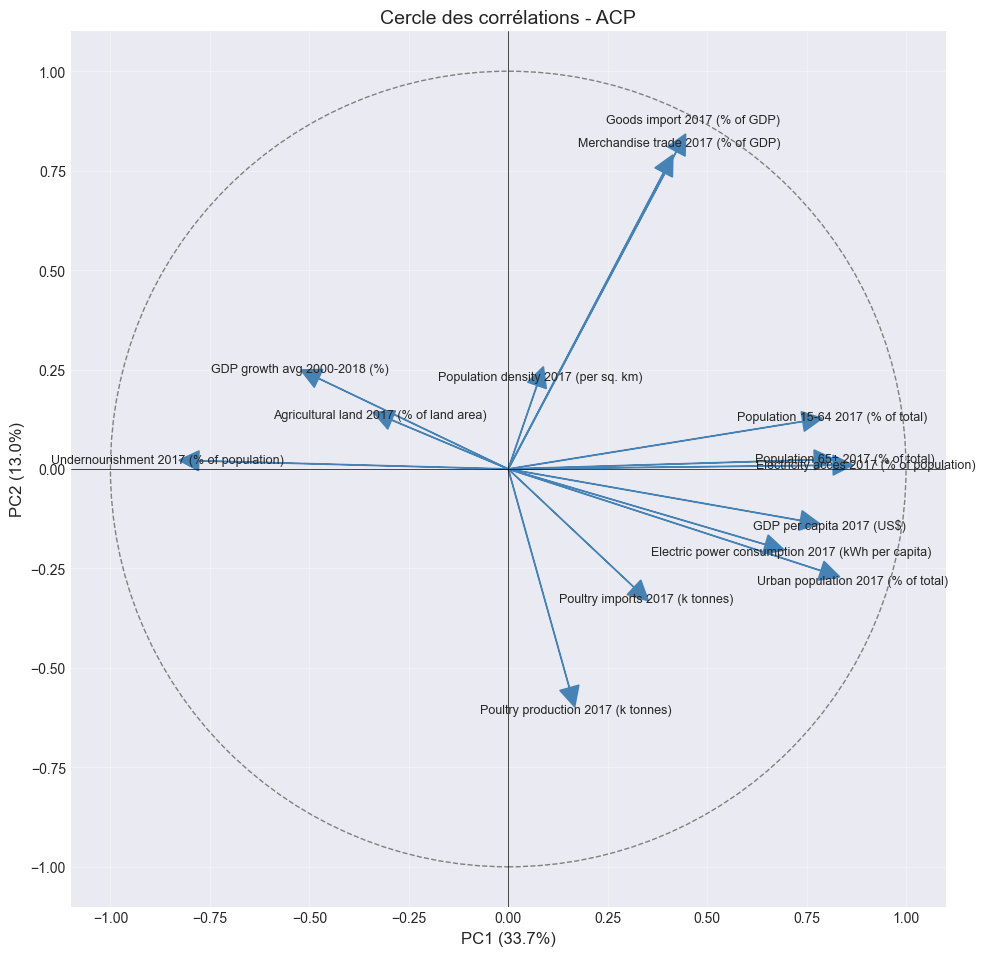

In [17]:
# Le cercle des corrélations montre comment les variables originales 
# contribuent aux deux premières composantes principales

# Fonctionnement de l'ACP :
#   1. Trouve les DIRECTIONS de variance maximale dans les données
#   2. Crée de NOUVEAUX AXES (composantes principales = PC1, PC2, PC3...)
#   3. Projette les données sur ces nouveaux axes
#   4. PC1 = direction avec la plus grande variance (info maximale)
#   5. PC2 = direction perpendiculaire à PC1 avec la 2ème plus grande variance
#   6. Et ainsi de suite pour PC3, PC4... jusqu'à PC14

from sklearn.decomposition import PCA

# 1. Créer l'objet PCA et calculer toutes les composantes
# PCA() sans argument = calculer toutes les composantes possibles
# Alternative : PCA(n_components=2) pour calculer seulement PC1 et PC2
pca = PCA()

# 2. Appliquer l'ACP sur les données standardisées
# fit_transform() = effectue 2 opérations en une seule étape :
#   1. fit() : apprend la structure des données (calcule les composantes principales)
#   2. transform() : projette les 128 pays sur les nouveaux axes PC1, PC2... PC14
## X_scaled = données d'entrée (128 pays × 14 variables standardisées)
# X_pca = données de sortie (128 pays × 14 nouvelles composantes principales)
X_pca = pca.fit_transform(X_scaled)

# 3. Calculer les coordonnées des VARIABLES sur le cercle de corrélations
# Le cercle de corrélations montre comment les 14 variables contribuent à PC1 et PC2
# pca.components_.T = transposée (14×14) pour avoir les variables en lignes
# pca.explained_variance_ = valeurs propres (variance capturée par chaque composante)
# np.sqrt() = racine carrée pour obtenir l'écart-type
correlations = pca.components_.T * np.sqrt(pca.explained_variance_)

# 4. Créer la figure pour le cercle des corrélations
# ax = axes du graphique pour dessiner ensuite
fig, ax = plt.subplots(figsize=(10, 10))

# 5. Dessiner le cercle de référence (rayon = 1)
cercle = plt.Circle(        # créer un objet cercle
    (0, 0),                 # centre du cercle à l'origine (0, 0)
     1,                     # radius = 1 (rayon du cercle)
     fill=False,            # cercle non rempli, seulement le contour
     color='gray', 
     linestyle='--')

ax.add_patch(cercle)        # Ajouter le cercle au graphique

# 6. Tracer les flèches pour CHAQUE variable (boucle sur 14 variables)
# enumerate() = obtenir à la fois l'index (i) et le nom de la variable
# i = 0, 1, 2... 13 (index de la variable)
# var = nom de la variable ("Poultry availability 2017", etc.)
for i, var in enumerate(df_numeric.columns):
    ax.arrow(0, 0,                           # Départ : origine (0,0)
             correlations[i, 0],             # Arrivée X : corrélation avec PC1
             correlations[i, 1],             # Arrivée Y : corrélation avec PC2
             head_width=0.05,                # head_width et head_length = taille de la tête de flèche
             head_length=0.05, 
             fc='steelblue',                 # facecolor = couleur de remplissage de la flèche
             ec='steelblue')                 # edgecolor = couleur du contour de la flèche
    
    # Ajouter le nom de la variable à l'extrémité de la flèche
    ax.text(correlations[i, 0] * 1.1,        # Position de  texte X légèrement décalée (10% au-delà)
            correlations[i, 1] * 1.1,        # Position de texte Y légèrement décalée (10% au-delà)
            var,                             # Nom de la variable à afficher
            fontsize=9,                      # Taille de police pour les étiquettes des variables
            ha='center',                     # Alignement horizontal centré
            va='center')                     # Alignement vertical centré

# 7. Définir les limites des axes X et Y : de -1.1 à +1.1
# Pour laisser un peu d'espace pour les étiquettes des variables
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)

# Dessiner les axes de référence passant par l'origine (0, 0)
ax.axhline(0, color='black', linewidth=0.5)  # Ligne horizontale à y=0
ax.axvline(0, color='black', linewidth=0.5)  # Ligne verticale à x=0

# Labels des axes avec le pourcentage de variance expliquée
ax.set_xlabel(
    f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)',  # proportion de variance expliquée par PC1
    fontsize=12)
ax.set_ylabel(
    f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', # proportion de variance expliquée par PC2
    fontsize=12)

ax.set_title('Cercle des corrélations - ACP', fontsize=14) # Titre du graphique

# Ajouter une grille légère pour faciliter la lecture
ax.grid(True, alpha=0.3)  # transparence de 30% pour ne pas surcharger

# Forcer un ratio d'aspect 1:1 pour avoir un cercle PARFAIT (pas d'ellipse)
ax.set_aspect('equal')

# Ajuster automatiquement la mise en page pour éviter que les éléments se chevauchent
plt.tight_layout()

# Afficher le graphique
plt.show()

PC1 et PC2 sont déterminées automatiquement par l'algorithme PCA. L'algorithme prend 14 variables initiales (électricité, population, etc.) et crée de nouvelles variables synthétiques : les composantes principales. Chaque composante principale est une combinaison pondérée des 9 variables.

* **PC1 (première composante principale) :** indique la direction de la variabilité maximale dans les données et capture la plus grande partie de l'information (généralement 40 à 60 %). 

* **PC2 (deuxième composante principale) :** direction de la deuxième plus grande variabilité, elle est toujours perpendiculaire à PC1 (indépendamment de PC1). 

Pour comprendre la signification de PC1 et PC2 il faut regarder le cercle des corrélations. Les variables avec de longues flèches vers la droite forment des valeurs PC1 positives. Les variables avec de longues flèches vers le haut forment des valeurs PC2 positives.

=====================================================================================================================================

**RÈGLES PRINCIPALES D'INTERPRÉTATION :** 

**1. LA LONGUEUR DE LA FLÈCHE** - c'est la force de la connexion avec les axes.
* Une flèche longue (proche du cercle, ~0,8-1,0)
    * La variable est BIEN représentée sur ces axes PC1-PC2.
    * Elle est FORTEMENT corrélée à l'une des composantes.
    * Elle peut être interprétée de manière FIABLE sur ce graphique.

* Flèche courte (proche du centre, ~0,2-0,5)
    * La variable est MAL représentée sur PC1-PC2
    * Ses informations se trouvent dans d'AUTRES composantes (PC3, PC4...)
    * Il est impossible de tirer des conclusions à son sujet uniquement à partir de PC1-PC2

**2. DIRECTION DE LA FLÈCHE** - influence sur les composants

* Flèche vers la droite (→) = la variable AUGMENTE PC1. Les pays ayant une valeur élevée pour cette variable ont un PC1 positif
* Flèche vers la gauche (←) = la variable DIMINUE PC1. Les pays ayant une valeur élevée pour cette variable ont un PC1 négatif
* Flèche vers le haut (↑) = la variable AUGMENTE PC2
* Flèche vers le bas (↓) = la variable DIMINUE PC2

**3. ANGLE ENTRE LES FLÈCHES** - corrélation entre les variables.

* Angle ≈ 0° (flèches parallèles →→) : les variables sont FORTEMENT corrélées positivement. Si l'une augmente, l'autre augmente également
* Angle ≈ 90° (flèches perpendiculaires ↑→). Les variables ne sont PAS corrélées (indépendantes). Il n'y a aucun lien entre elles.
* Angle ≈ 180° (flèches opposées →←). Les variables sont FORTEMENT corrélées négativement. Si l'une augmente, l'autre diminue. 

=====================================================================================================================================

**INTERPRÉTATION DU CERCLE DE CORRÉLATION :**

* **PC1 :** NIVEAU DE DÉVELOPPEMENT ÉCONOMIQUE
    * Variables à droite (forment les valeurs positives PC1) : Electricity access 2017, GDP per capita 2017, Electric power consumption 2017, Urban population 2017 (% of total). Variables à gauche (formant les valeurs négatives PC1) : Undernourishment 2017 (% of population). Les pays ayant des valeurs élevées sur l’axe PC1 sont des pays économiquement développés, riches et urbanisés avec un niveau de revenu élevé et une infrastructure avancée. Les pays avec de faibles valeurs sur l’axe C1 sont des pays moins développés confrontés à des problèmes de pauvreté et de malnutrition.

* **PC2 :** IMPORTATION VS. PRODUCTION
    * Variables en haut (forment les valeurs positives PC2) : Goods import 2017 (% of GDP), Merchandise trade 2017 (% of GDP). Variables en bas (formant les valeurs négatives PC2) : Poultry production 2017 (k tonnes), Poultry imports 2017. Les pays avec des valeurs élevées sur l’axe PC2 sont des économies fortement impliquées dans le commerce international et dépendantes des importations/exportations. Les pays avec de faibles valeurs sur l’axe PC2 sont caractérisés par des volumes élevés de production et d’importation de volaille. 

### 3. Scree plot

Est un graphique qui montre le pourcentage d'informations capturé par chaque composante principale - pour déterminer le nombre de composantes à conserver pour une analyse plus approfondie. Sur les 14 variables disponibles dans l'analyse, 14 composantes principales seront créées en conséquence. Mais il est inutile d'utiliser les 14, car cela irait à l'encontre de l'idée même de simplification des données. Le scree plot aide à sélectionner 2, 3 ou 4 composantes qui contiennent un maximum d'informations.

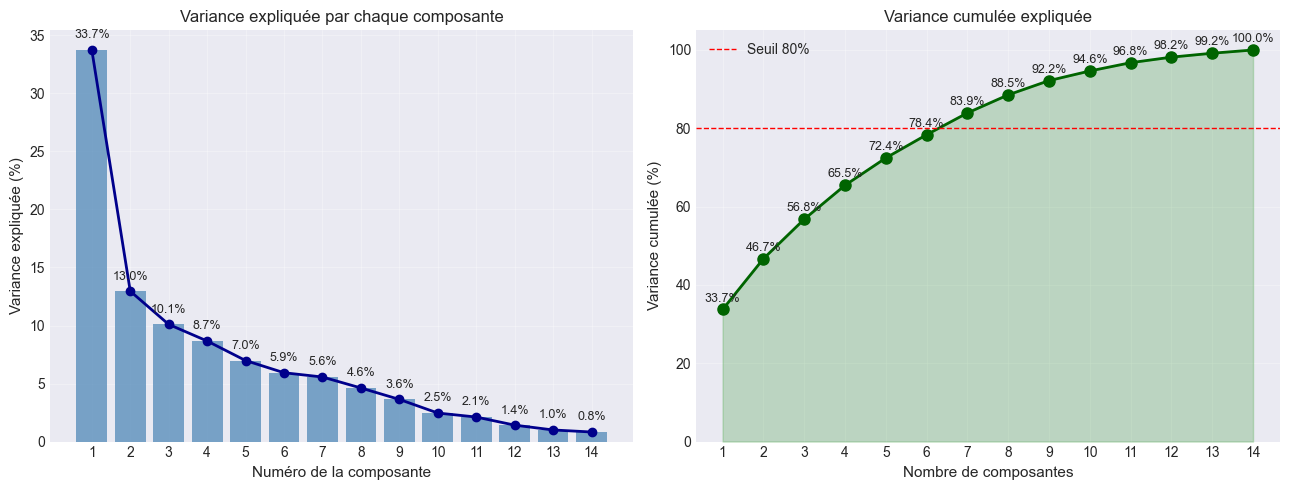

In [48]:
# Le scree plot aide à décider combien de composantes garder
# on garde les composantes avant le "coude" (elbow) du graphique
# C'est un outil de DÉCISION pour réduire la dimensionnalité

# Créer une figure avec 2 sous-graphiques côte à côte
# plt.subplots(1, 2) = créer une grille de 1 ligne × 2 colonnes
# (ax1, ax2) = récupérer les 2 axes pour dessiner séparément
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# GRAPHIQUE 1 : Variance expliquée par chaque composante
# Extraire le pourcentage de variance expliquée par chaque composante
# pca.explained_variance_ratio_ = tableau numpy avec 14 valeurs (une par composante)
# * 100 = convertir en pourcentage pour faciliter la lecture
variance_expliquee = pca.explained_variance_ratio_ * 100

composantes = range(1, len(variance_expliquee) + 1) # Créer la liste des numéros de composantes (1 à 14)

# Dessiner les barres verticales pour chaque composante
ax1.bar(                       # créer un diagramme à barres sur le premier graphique
    composantes,               # positions X des barres (1, 2, 3... 9)       
    variance_expliquee,        # hauteurs des barres (pourcentage de variance)
    color='steelblue',         # couleur bleu acier
    alpha=0.7)                 # transparence de 70% pour voir les autres éléments

# Superposer une courbe avec des marqueurs ronds
ax1.plot(
    composantes,               # positions X des points (1, 2, 3... 9)
    variance_expliquee,        # hauteurs des points (mêmes que les barres)
    'o-',                      # cercles reliés par des lignes
    color='darkblue', 
    linewidth=2)               # épaisseur de la ligne

# Configurer les labels et le titre du premier graphique
ax1.set_xlabel('Numéro de la composante', fontsize=11)
ax1.set_ylabel('Variance expliquée (%)', fontsize=11)
ax1.set_title('Variance expliquée par chaque composante', fontsize=12)
ax1.set_xticks(composantes)  # Forcer l'affichage de TOUS les numéros de composantes sur l'axe X
ax1.grid(True, alpha=0.3)    # Ajouter une grille légère pour faciliter la lecture des valeurs

# Ajouter les VALEURS EXACTES au-dessus de chaque barre
for i, v in enumerate(variance_expliquee):  # enumerate() = obtenir à la fois l'index (i) et la valeur (v)
     ax1.text(                   # ajouter du texte sur le graphique      
        i + 1,                   # position X (numéro de la composante)
        v + 1,                   # position Y au-dessus de la barre (décalage de 1%)
        f'{v:.1f}%',             # formater la valeur avec 1 décimale et le signe %
        ha='center',             # aligner le texte au centre horizontalement
        fontsize=9)

# GRAPHIQUE 2 : Variance cumulée (somme progressive)
# Calculer la variance cumulée avec np.cumsum()
# Chaque valeur = SOMME de toutes les précédentes
# Pour voir combien de composantes sont nécessaires pour atteindre 80% de variance
variance_cumulee = np.cumsum(variance_expliquee)

# Dessiner la courbe de variance cumulée
ax2.plot(composantes,            # positions X (1, 2, 3... 9)
         variance_cumulee,       # hauteurs des points (variance cumulée)
         'o-',                   # cercles reliés par des lignes
         color='darkgreen', 
         linewidth=2,            # épaisseur de la ligne
         markersize=8)           # taille des marqueurs

# Ajouter une ligne horizontale rouge à 80% (seuil standard en ACP)
ax2.axhline(80, color='red', linestyle='--', linewidth=1, label='Seuil 80%')

# Remplir la zone sous la courbe avec une couleur verte transparente
ax2.fill_between(composantes, variance_cumulee, alpha=0.2, color='green')

# Configurer les labels et le titre du deuxième graphique
ax2.set_xlabel('Nombre de composantes', fontsize=11)
ax2.set_ylabel('Variance cumulée (%)', fontsize=11)
ax2.set_title('Variance cumulée expliquée', fontsize=12)
ax2.set_ylim(0, 105)           # 105% pour laisser de l'espace pour les étiquettes
ax2.set_xticks(composantes)    # Afficher tous les numéros
ax2.grid(True, alpha=0.3)      # Grille légère
ax2.legend()                   # Afficher la légende (ligne rouge "Seuil 80%")

# Ajouter les valeurs exactes sur chaque point de la courbe
for i, v in enumerate(variance_cumulee):
    # i = 0, 1, 2... 14 (index de la composante)
    # v = valeur de la variance cumulée à cette composante
    # i + 1 = position X (numéro de la composante)
    # v = variance cumulée = position Y sur la courbe
    # v + 2 = position Y au-dessus du point (décalage de 2%)
    ax2.text(i + 1, v + 2, f'{v:.1f}%', ha='center', fontsize=9)

# Afficher les deux graphiques

plt.tight_layout()  # Ajuster automatiquement l'espacement entre les graphiques
plt.show()          # Afficher la figure complète avec les 2 sous-graphiques

**Le graphique comporte deux parties :**
* À gauche, les colonnes indiquent la contribution de chaque composante (PC1 est la plus importante, PC2 la deuxième, etc.)
* À droite, la ligne cumulative indique le pourcentage d'informations accumulées. 

**Resultat :** Il est optimale d'utiliser 4 composantes pour la clustérisation. 
  - PC1 + PC2 + PC3 + PC4 = 66 % de variance totale
  - PC1 (33.7%) = Niveau de développement
  - PC2 (13.0%) = Importation ou production
  - PC3 (10.1%) = ?
  - PC4 (8.7%) = ?

### 4. Recherche et interprétation des composantes PC3 - PC4

In [49]:
# Pour comprendre la signification des composantes 3 - 4 AVANT de les utiliser
# il faut analyser les LOADINGS (corrélations entre variables et composantes)
# Un loading élevé indique qu'une variable contribue fortement à la composante

# Extraire les loadings (corrélations) pour PC3 - PC4
loadings_pc3 = correlations[:, 2]       # Extraire la 3ème colonne (index 2) qui contient les corrélations avec PC3
loadings_pc4 = correlations[:, 3]       # Extraire la 4ème colonne (index 3) qui contient les corrélations avec PC4

# Créer un DataFrame avec toutes les informations nécessaires et
# valeurs absolues pour faciliter le tri (ignorer le signe +/-)
df_loadings = pd.DataFrame({
    'Variable': df_numeric.columns,        # Noms des 14 variables
    'PC3': loadings_pc3,                   # Corrélation avec PC3 (de -1 à +1)
    'PC4': loadings_pc4,                   # Corrélation avec PC4 (de -1 à +1)
    'PC3_abs': np.abs(loadings_pc3),       # Valeur absolue pour PC3
    'PC4_abs': np.abs(loadings_pc4)        # Valeur absolue pour PC4
})

# Afficher les variables les plus importantes pour PC3, PC4

# Créer une fonction pour afficher les loadings d'une composante
def display_component_loadings(pc_name, pc_variance, df_loadings):
    """Affiche un résumé des loadings pour une composante principale donnée."""
    print("\n" + "="*70)
    print(f" {pc_name} ({pc_variance*100:.1f}% de variance)")
    print("="*70)
    
    # Trier les variables par la valeur absolue de leur contribution pour voir les plus importantes en haut
    df_sorted = df_loadings[['Variable', pc_name]].copy()
    df_sorted['Abs_Loading'] = df_sorted[pc_name].abs()
    df_sorted = df_sorted.sort_values('Abs_Loading', ascending=False).drop(columns='Abs_Loading')
    
    # Afficher le tableau des loadings
    print(df_sorted.to_string(index=False))
    
    # Interprétation résumée
    top_positive = df_sorted[df_sorted[pc_name] > 0].head(2)
    top_negative = df_sorted[df_sorted[pc_name] < 0].head(2)
    
    print(f"\n{pc_name} oppose :")
    print(f"  - POSITIF (+): {', '.join(top_positive['Variable'])}")
    print(f"  - NÉGATIF (-): {', '.join(top_negative['Variable'])}")

# Afficher les loadings pour PC3, PC4
display_component_loadings('PC3', pca.explained_variance_ratio_[2], df_loadings)
display_component_loadings('PC4', pca.explained_variance_ratio_[3], df_loadings)


 PC3 (10.1% de variance)
                                        Variable       PC3
                    GDP growth avg 2000-2018 (%)  0.476778
              Population 15-64 2017 (% of total)  0.459572
              Poultry production 2017 (k tonnes)  0.408860
        Electricity acces 2017 (% of population)  0.403347
Electric power consumption 2017 (kWh per capita) -0.379370
                       GDP per capita 2017 (US$) -0.372888
         Undernourishment 2017 (% of population) -0.359704
         Agricultural land 2017 (% of land area)  0.325423
            Population density 2017 (per sq. km)  0.300444
                    Goods import 2017 (% of GDP) -0.124884
                 Poultry imports 2017 (k tonnes)  0.099772
                Population 65+ 2017 (% of total) -0.098933
              Urban population 2017 (% of total) -0.087651
               Merchandise trade 2017 (% of GDP) -0.066197

PC3 oppose :
  - POSITIF (+): GDP growth avg 2000-2018 (%), Population 15-64 2017 (% of 

PC3 (10.1%) : **"Profil démographique et maturité économique"**. 

* Cet axe est « croissance économique et population jeune » versus « richesse et forte consommation ». 
* Positives - pays avec des économies en croissance et une population jeune. 
* Négatives - pays avec un PIB par habitant élevé et une consommation d’énergie élevée

PC4 (8.7%) : **"Dépendance aux importations agricoles"**. 

* Cet axe est « dépendance agraire et importation de volaille » versus « croissance économique et infrastructure ». 
* Positives - pays qui sont des importateurs actifs de volaille, avec une agriculture développée et une forte densité de population. 
* Négatives - pays avec des économies dynamiques, une population jeune et de meilleures infrastructures.

**REMARQUE IMPORTANTE !** СP4 peut double СР2 dans une certaine mesure, de sorte que СР4 peut être supprimée plus tard pour le raffinement du cluster.

==========================================================================================================================================

Pour « La poule qui chante », les marchés cibles idéaux sont ceux où :

* PC1 : **valeurs positives** (pays économiquement développés, riches, urbanisés, avec un haut niveau de vie et une infrastructure avancée) : ils disposent d’un fort pouvoir d’achat, d’une logistique fiable (chaîne du froid) et sont capables de payer pour des produits importés de qualité. Ce sont des pays économiquement développés, riches et urbanisés avec de bonnes infrastructures, un PIB par habitant élevé et un accès presque complet à l’électricité. Ces pays ont une forte demande et sont en mesure de fournir la logistique (chaîne du froid).

* PC2 : **valeurs positives** (économies très ouvertes, fortement impliquées dans le commerce international, forte part des importations dans le PIB) : ces pays dépendent des importations alimentaires, sont habitués à acheter à l’étranger et sont ouverts aux nouveaux fournisseurs. Il s’agit de pays fortement impliqués dans le commerce international et dépendants des importations (forte importation de biens par rapport au PIB, forte activité commerciale). Ils ne couvrent pas la demande intérieure avec leurs propres produits et sont ouverts aux fournisseurs externes.

* PC3 : **valeurs négatives à modérées** (PIB/habitant élevé, forte consommation, maturité économique) : ils ont le pouvoir d'achat et une demande existante. Ces pays présentent un niveau de développement avancé, une population plutôt mature (faible croissance démographique), un pouvoir d’achat élevé et une consommation alimentaire déjà importante. Ils sont donc solvables, disposent d’une demande existante pour la volaille et sont habitués à consommer des produits importés de qualité. Ce sont des marchés stables, où la croissance de la demande est modérée mais les volumes sont importants et la concurrence se fait sur la qualité.

### 4. Projection des pays

Visualisation des valeurs : projections 2D par paires (PC1 - PC3)

In [52]:
import plotly.express as px      # Importer plotly.express pour les graphiques interactifs

# Créer un DataFrame avec les coordonnées des pays 
# sur les 3 composantes principales
df_pca_3d = pd.DataFrame( 
    X_pca[:, :3],                                       # Prendre les 3 premières colonnes (PC1 à PC3)
    columns=['PC1', 'PC2', 'PC3'],                       # Noms des colonnes
    index=df.index)                                     # Garder les mêmes indices que le DataFrame original (noms des pays)

df_pca_3d['Country'] = df['Country'].values             # Ajouter les noms des pays pour l'affichage au survol

# Créer la matrice de graphiques
# Utiliser px.scatter_matrix pour afficher toutes les paires de composantes.
fig = px.scatter_matrix(df_pca_3d, 
                        dimensions=['PC1', 'PC2', 'PC3'],
                        hover_name='Country',
                        title='Matrice des projections 2D des pays sur les 3 composantes principales',
                        height=1000, # Augmenter la taille pour une meilleure lisibilité
                        width=1000)

# Améliorer l'apparence des points pour qu'ils soient plus visibles.
fig.update_traces(                       # Appliquer les modifications à tous les sous-graphiques
    diagonal_visible=False,              # Ne pas afficher les histogrammes sur la diagonale
    marker=dict(size=5, opacity=0.7))    # Taille et transparence des points

fig.show()

# V. CLUSTERING

**Il s'agit d'une division automatique de pays en groupes (clusters)** de manière à ce que les pays au sein d'un même groupe soient similaires, mais différents entre les groupes.

## 1. Classification Ascendante Hiérarchique (CAH)

* **Fonctionnement :** CAH construit un arbre hiérarchique (dendrogramme) en commençant par chaque pays comme un cluster distinct, puis en regroupant progressivement les groupes les plus similaires vers le haut de l'arbre. À chaque niveau, les deux groupes les plus proches sont « fusionnés » en un seul. Le résultat est un arbre complet allant de 170 pays distincts à 1 cluster mondial. Il faut choisir à quelle « hauteur » de l'arbre le « couper » pour obtenir le nombre de clusters souhaité.

* **Avantage :** la structure complète des relations entre les pays (quels sont les voisins, lesquels sont éloignés) est visible. Vous pouvez choisir N'IMPORTE QUEL nombre de clusters sans recalcul. Il n'est pas nécessaire de connaître à l'avance la valeur optimale de k. Il trouve facilement les petits groupes ou les groupes inhabituels (les anomalies sont immédiatement visibles). La visualisation (arbre) est intuitive.

* **Désavantage :** algorithme lent (acceptable pour 128 pays, mais trop lent pour des millions de données). Décisions irréversibles : une fusion précoce incorrecte ne peut pas être « annulée » ultérieurement. Sensible aux valeurs aberrantes : un seul composant atypique peut fausser toute la structure. Il est plus difficile d'évaluer la qualité du regroupement. Le dendrogramme de 128 pays est assez illisible.

* **Résultat :** le dendrogramme montre quels pays sont proches.

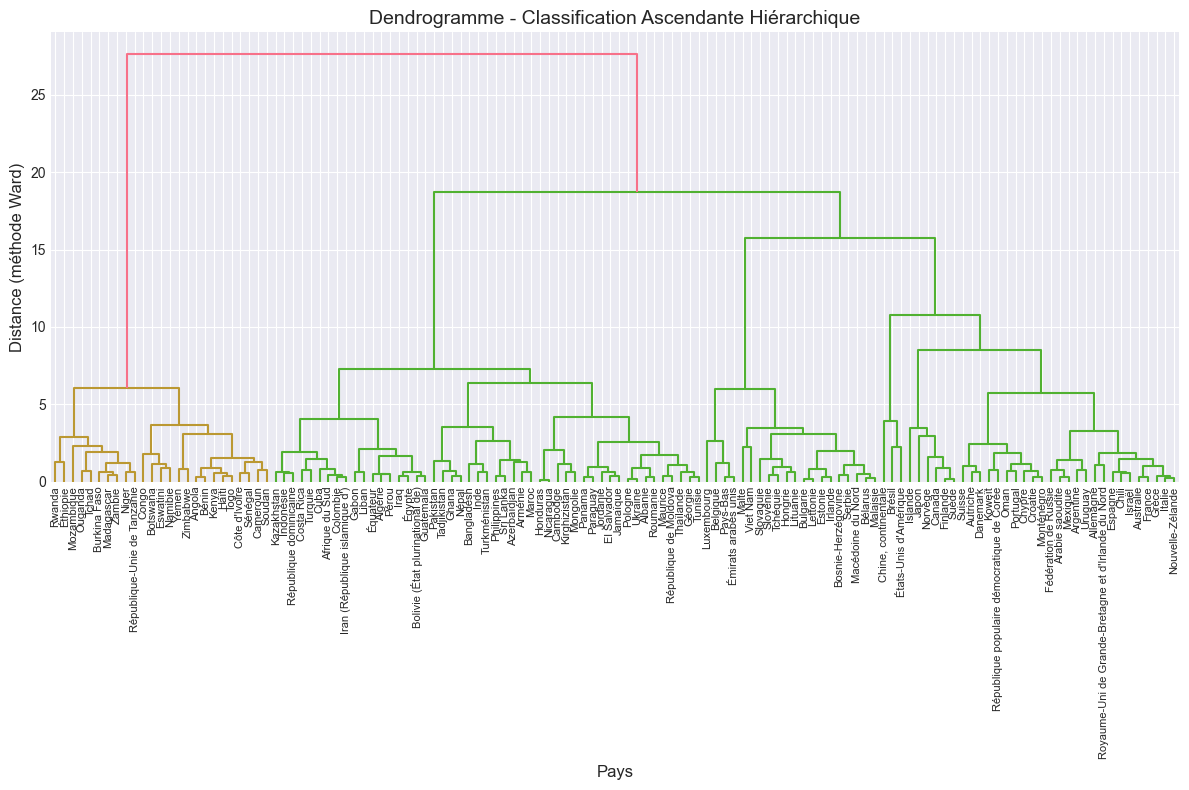

In [56]:
# CAH visualisation : Dendrogramme

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import matplotlib.pyplot as plt

# 1. Calcul de la matrice de liaison (linkage matrix)
linkage_matrix = linkage(                       # fonction scipy qui calcule les distances et les regroupements
                        X_pca[:, :3],           # utilisation des 3 premières composantes PCA (66% de variance)
                        method='ward',          # méthode de regroupement qui minimise la variance intra-cluster
                        metric='euclidean')     # distance euclidienne pour mesurer la similarité entre les pays

# 2. Construction du dendrogramme
plt.figure(figsize=(12, 8))                     # créer une grande figure pour le dendrogramme
dendrogram(linkage_matrix,                      # construire le dendrogramme à partir de la matrice de liaison
           labels=df['Country'].values,         # afficher les noms des pays au lieu de numéros sur l'axe X
           leaf_rotation=90,                    # faire pivoter les étiquettes des pays à 90° pour les rendre lisibles
           leaf_font_size=8)                    # réduire la taille de la police des étiquettes pour éviter le chevauchement

# Configuration du graphique
plt.title('Dendrogramme - Classification Ascendante Hiérarchique', fontsize=14)
plt.xlabel('Pays', fontsize=12)
plt.ylabel('Distance (méthode Ward)', fontsize=12)
plt.tight_layout()
plt.show()

In [81]:
# Découpage en clusters (choix du nombre de clusters)

clusters_cah = fcluster(      # coupe le dendrogramme à une hauteur donnée pour former des clusters
    linkage_matrix,           # matrice de liaison calculée précédemment
    t=7,                      # nombre de clusters souhaité (à ajuster selon le dendrogramme)
    criterion='maxclust')     # critère de découpage : former au maximum 4 clusters

# Ajouter la colonne des clusters CAH au DataFrame original pour l'analyse ultérieure
df['Cluster_CAH'] = clusters_cah 

# 4. Afficher la répartition des pays dans chaque cluster
print("Répartition des pays par cluster (CAH) :")
print(
    df['Cluster_CAH'].        # prendre la colonne des clusters
    value_counts().           # compte le nombre d'occurrences de chaque valeur unique
    sort_index())             # trie par numéro de cluster (1, 2, 3, 4) au lieu de par taille

# Aperçu des pays dans chaque cluster
print("\n")
print("Apreçu des pays par cluster :")

# Parcourir chaque cluster et afficher les premiers pays
for cluster in sorted(df['Cluster_CAH'].unique()):
    # df[df['Cluster_CAH'] == cluster] = filtrer seulement les pays de ce cluster
    # ['Country'] = prendre seulement la colonne des noms de pays
    # .head(10) = prendre les 10 premiers pays (au lieu de tous)
    # .tolist() = convertir en liste Python pour un affichage propre
    cluster_countries = df[df['Cluster_CAH'] == cluster]['Country'].head(10).tolist()
    
    print(f"\nCluster {cluster} (premiers 10 pays) :")
    print(cluster_countries)
    
    # Ajouter le nombre total de pays si le cluster en contient plus de 10
    total_in_cluster = len(df[df['Cluster_CAH'] == cluster])
    if total_in_cluster > 10:
        print(f"    ... et {total_in_cluster - 10} autres pays dans ce cluster")

Répartition des pays par cluster (CAH) :
Cluster_CAH
1    25
2    18
3    31
4    20
5     3
6     6
7    25
Name: count, dtype: int64


Apreçu des pays par cluster :

Cluster 1 (premiers 10 pays) :
['Angola', 'Botswana', 'Burkina Faso', 'Bénin', 'Cameroun', 'Congo', "Côte d'Ivoire", 'Eswatini', 'Haïti', 'Kenya']
    ... et 15 autres pays dans ce cluster

Cluster 2 (premiers 10 pays) :
['Afrique du Sud', 'Algérie', 'Bolivie (État plurinational de)', 'Colombie', 'Costa Rica', 'Cuba', 'Gabon', 'Guatemala', 'Indonésie', "Iran (République islamique d')"]
    ... et 8 autres pays dans ce cluster

Cluster 3 (premiers 10 pays) :
['Albanie', 'Arménie', 'Azerbaïdjan', 'Bangladesh', 'Cambodge', 'El Salvador', 'Ghana', 'Géorgie', 'Honduras', 'Inde']
    ... et 21 autres pays dans ce cluster

Cluster 4 (premiers 10 pays) :
['Belgique', 'Bosnie-Herzégovine', 'Bulgarie', 'Bélarus', 'Estonie', 'Hongrie', 'Irlande', 'Lettonie', 'Lituanie', 'Luxembourg']
    ... et 10 autres pays dans ce cluster

Clust

**INTERPRÉTATION DU DIAGRAMME**

NE PAS lire les noms des différents pays, mais regarder la STRUCTURE de l'arbre depuis le haut.

* Les branches principales (lignes verticales épaisses) sont des clusters potentiels.
* La hauteur à laquelle les branches se rejoignent indique la différence entre les groupes.
* Où « couper » l'arbre : choisir le nombre de clusters.

Dans ce cas, il existe 4 clusters potentiels, et l'aperçu des pays affiche la liste des pays dans chaque cluster potentiel.

## 2. K-means

* **Fonctionnement :** il s'agit d'un algorithme itératif de partitionnement des données qui minimise la dispersion intra-cluster (inertie). Le processus se déroule en plusieurs étapes :  k centroïdes (centres de clusters) sont placés de manière aléatoire dans l'espace des caractéristiques, chaque observation est attribuée au centroïde le plus proche. Les étapes sont répétées jusqu'à convergence (lorsque les affectations ne changent plus ou que la variation de l'inertie devient négligeable). Le résultat final est la division de l'ensemble des données en k groupes compacts non chevauchants, où chaque observation appartient au cluster dont le centroïde est le plus proche.

* **Avantage :** algorithme rapide et simple (même pour les données volumineuses). Donne des clusters clairs et compacts (bien séparés). Il existe des mesures objectives de la qualité (score Silhouette). C'est la norme dans l'industrie (utilisée partout). Il est facile de convertir les résultats en décisions commerciales (profils clairs). Fonctionne bien avec 4 à 5 clusters.

* **Désavantage :** il faut choisir k à l'avance. La hiérarchie entre les clusters n'est pas visible (ils sont « égaux »). Peut créer des clusters « étranges » si les données contiennent des valeurs aberrantes. Ne convient pas si vous avez besoin de comprendre TOUTE la structure, et non une division spécifique.

* **Méthode du coude (elbow method) :** le graphique aide à choisir le nombre optimal de clusters.

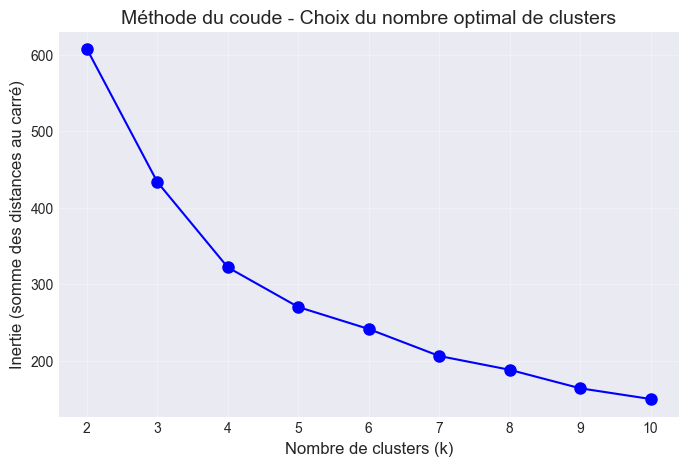

In [82]:
# ============================================================================
# K-MEANS CLUSTERING
# ============================================================================
# K-means répartit les pays en k groupes pré-définis de manière optimale.
# Avantage : rapide, simple, standard industriel.
# Désavantage : nécessite de connaître k à l'avance.

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

# ============================================================================
# ÉTAPE 1 : Méthode du coude (Elbow Method) pour choisir k
# ============================================================================
# Tester différents nombres de clusters (2 à 10) et mesurer l'inertie
# Inertie = somme des distances au carré des points à leur centroïde
# Plus k augmente, plus l'inertie diminue (mais risque de sur-apprentissage)

inerties = []  # Liste pour stocker les inerties
k_range = range(2, 11)  # Tester k de 2 à 10

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca[:, :3])  # Utiliser les 3 premières composantes PCA
    inerties.append(kmeans.inertia_)

# Graphique du coude
plt.figure(figsize=(8, 5))
plt.plot(k_range, inerties, 'bo-', markersize=8)
plt.xlabel('Nombre de clusters (k)', fontsize=12)
plt.ylabel('Inertie (somme des distances au carré)', fontsize=12)
plt.title('Méthode du coude - Choix du nombre optimal de clusters', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

**INTERPRÉTATION DU GRAPHIQUE « MÉTHODE DU COUDE »**

Le graphique montre **une baisse monotone et régulière sans « coude » prononcé**, ce qui indique l'absence d'une structure naturelle avec un nombre clairement optimal de clusters dans les données. C'est une situation typique pour les données économiques réelles, où les pays forment un continuum de caractéristiques plutôt que des groupes clairement distincts. La ligne montre que l'ajout de chaque nouveau cluster continue de réduire l'inertie, mais que le rythme de la baisse diminue progressivement et non brusquement. Dans de tels cas, le choix du nombre de clusters n'est pas basé sur la géométrie du graphique, mais sur d'autres critères : les résultats de la classification hiérarchique CAH, la logique commerciale du projet, l'interprétabilité des résultats, etc.

In [88]:
# ============================================================================
# ÉTAPE 2 : Appliquer l'algorithme K-means
# ============================================================================
# Définir le nombre optimal de clusters
k_optimal = 7

# Initialiser et exécuter K-means
# n_init=10 : lancer l'algorithme 10 fois pour un résultat plus stable
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
clusters_kmeans = kmeans.fit_predict(X_pca[:, :3])

# Ajouter les résultats au DataFrame principal
df['Cluster_KMeans'] = clusters_kmeans

# Ajouter les valeurs des composantes principales au DataFrame pour l'analyse
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]
df['PC3'] = X_pca[:, 2]

# Affichage du nombre de pays par cluster
print("\nRépartition des pays par cluster (K-means) :")
print(df['Cluster_KMeans'].value_counts().sort_index())


Répartition des pays par cluster (K-means) :
Cluster_KMeans
0     3
1    19
2    23
3    25
4    12
5    26
6    20
Name: count, dtype: int64


## 3. Comparaison CAH и K-means

**Le Silhouette Score** (coefficient de silhouette) est une mesure de la qualité du regroupement qui évalue dans quelle mesure chaque objet se trouve « dans son » cluster. Il mesure la densité interne : la proximité des objets au sein de leur cluster et la séparation externe : la distance entre le cluster et les autres clusters. Plage de -1 à 1 :
* 0,5 = excellent (les clusters sont clairement séparés)
* 0,3-0,5 = bon (séparation normale)
* < 0,3 = faible (les clusters se chevauchent)

**!!! NOTE IMPORTANTE :**

CLUSTERING a été effectué deux fois. La première analyse a été réalisée en tenant compte du composite PC1-PC4, et les deux résultats de classification ont montré une faible délinéation des clusters : Score de silhouette CAH  = 0,289 et Score de silhouette K-signifie : 0,298.  En tenant compte du critère Score de silhouette < 0.3 = faible (les clusters se chevauchent), il a été décidé de répéter le regroupement avec 3 composites PC1-PC3, et ce regroupement a donné un résultat plus élevé, Score de silhouette CAH  = 0.319 et Score de silhouette K-means = 0.355. Il a été décidé de poursuivre l’analyse plus approfondie des clusters en tenant compte des trois premiers composites.

In [89]:
# COMPARAISON DES SILHOUETTE SCORES : CAH vs K-MEANS

from sklearn.metrics import silhouette_score

silhouette_cah = silhouette_score(                         # Calcul du Silhouette Score pour CAH
                                  X_pca[:, :3],            # Utiliser les 3 premières composantes PCA
                                  df['Cluster_CAH'])       # Prendre les clusters CAH pour le calcul du score

silhouette_kmeans = silhouette_score(                      # Calcul du Silhouette Score pour K-means
                                    X_pca[:, :3],          # Utiliser les 3 premières composantes PCA
                                    df['Cluster_KMeans'])  # Prendre les clusters K-means pour le calcul du score

# Affichage des résultats
print(f"\nSilhouette Score CAH     : {silhouette_cah:.3f}")
print(f"Silhouette Score K-means : {silhouette_kmeans:.3f}")



Silhouette Score CAH     : 0.310
Silhouette Score K-means : 0.324


La valeur actuelle se situe entre 0,3 et 0,5, ce qui est caractéristique des données économiques et sociales réelles, où les frontières entre les groupes sont naturellement floues. Le coefficient montre que les pays au sein de chaque cluster sont relativement proches les uns des autres, mais qu'il existe un certain chevauchement entre les clusters voisins. Ce résultat n'est pas un défaut de l'analyse, mais reflète plutôt la complexité objective des données : les indicateurs économiques des pays forment un continuum plutôt que des catégories discrètes. Une valeur supérieure à 0,3 est considérée comme acceptable pour les tâches d'analyse commerciale et suffisante pour formuler des recommandations pratiques. Des valeurs de silhouette plus élevées (supérieures à 0,5-0,6) sont rares dans les études socio-économiques et indiquent généralement soit une simplicité excessive des données, soit un nombre trop faible de clusters. Dans le contexte du projet d'exportation de volaille, le coefficient de 0,334 confirme que les quatre groupes de pays identifiés présentent une homogénéité interne suffisante pour élaborer des stratégies marketing ciblées.

# VI. ANALYSE DES CLUSTERS

**PROFILAGE DES CLUSTERS** - de décrire chaque groupe et de comprendre en quoi il diffère des autres. Le profilage répond aux questions suivantes - Quel est le portrait type des pays de chaque cluster ? Quelles sont les variables caractéristiques de chaque groupe ? Quel nom donner au cluster à la place du numéro ?

### 1. Création un DataFrame avec les valeurs moyennes par cluster

In [94]:
# Nombre de pays par cluster
print("RÉPARTITION DES PAYS PAR CLUSTER\n")
print(df['Cluster_KMeans'].value_counts().sort_index())

# Sélectionner les colonnes des composantes principales pour l'analyse
colonnes_pca = ['PC1', 'PC2', 'PC3']
print(f"\nColonnes utilisées pour l'analyse des clusters : {colonnes_pca}\n")

# Calculer la moyenne de chaque CP pour chaque cluster
cluster_profiles_pca = df.groupby('Cluster_KMeans')[colonnes_pca].mean().round(2)

print("\nMOYENNES DES COMPOSANTES PRINCIPALES PAR CLUSTER\n")
print(cluster_profiles_pca)

RÉPARTITION DES PAYS PAR CLUSTER

Cluster_KMeans
0     3
1    19
2    23
3    25
4    12
5    26
6    20
Name: count, dtype: int64

Colonnes utilisées pour l'analyse des clusters : ['PC1', 'PC2', 'PC3']


MOYENNES DES COMPOSANTES PRINCIPALES PAR CLUSTER

                 PC1   PC2   PC3
Cluster_KMeans                  
0               1.29 -4.04  2.73
1               2.46 -1.10 -1.10
2              -3.49 -0.11 -1.07
3               0.11 -0.96  0.43
4               2.59  2.12 -0.37
5               0.84  0.94  0.46
6              -1.30  0.49  0.95


### 2. Visualisation des СРs analysées pour chaque cluster

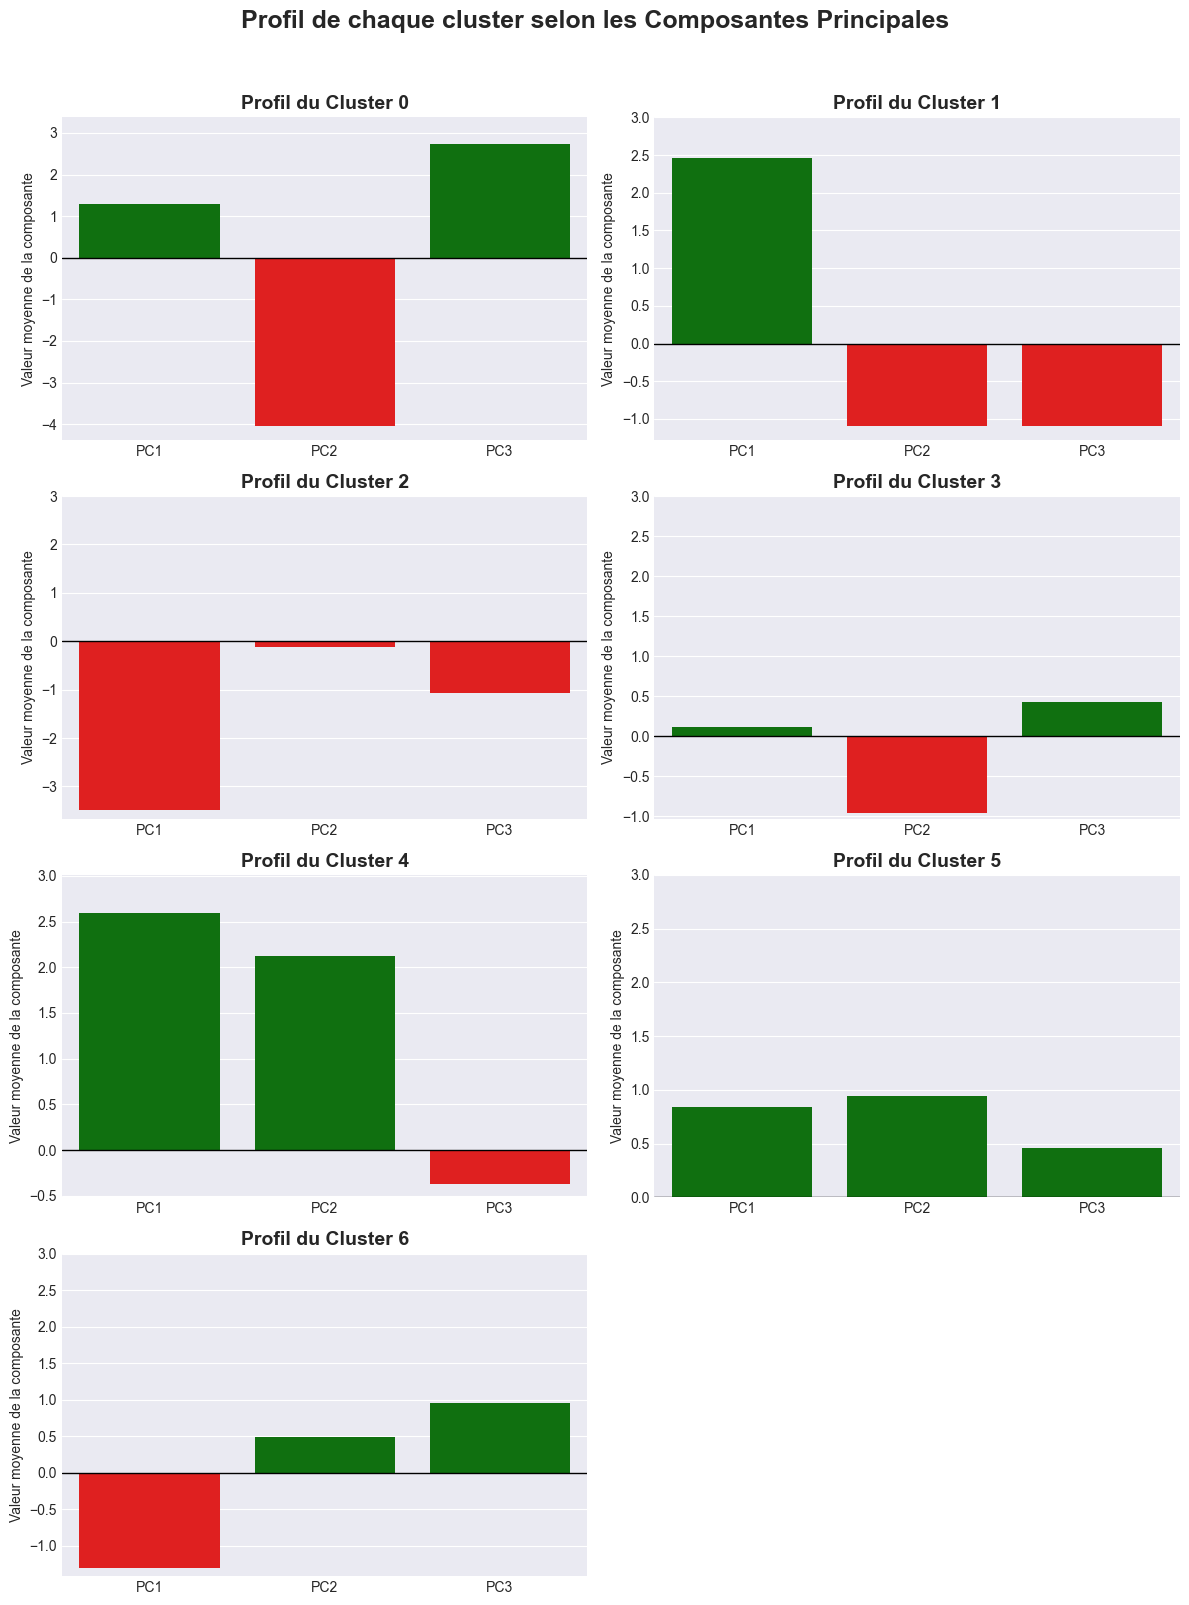

In [99]:
import seaborn as sns

# Créer une grille pour 7 graphiques (4 lignes, 2 colonnes)
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12, 16))
axes = axes.flatten() # Convertir en un tableau pour un accès facile

# Boucle sur chaque cluster
for i, cluster_num in enumerate(cluster_profiles_pca.index):
    ax = axes[i]
    
    # Obtenir les données pour le cluster actuel
    profile = cluster_profiles_pca.loc[cluster_num]
    
    # Définir les couleurs : vert pour positif, rouge pour négatif
    colors = ['green' if val >= 0 else 'red' for val in profile.values]
    
    # Créer le diagramme en barres pour le cluster
    sns.barplot(
        x=profile.index,              # Les composantes principales (PC1, PC2, PC3) sur l'axe des x
        y=profile.values,             # Les valeurs moyennes de chaque composante sur l'axe des y
        ax=ax,                        # Dessiner sur l'axe actuel de la grille
        palette=colors,               # Couleurs personnalisées pour chaque barre (vert ou rouge)
        hue=profile.index,            # Utiliser les noms des composantes comme légende pour différencier les barres
        legend=False)                 # Ne pas afficher la légende (hue) pour éviter la redondance
    
    ax.set_title(f'Profil du Cluster {cluster_num}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Valeur moyenne de la composante', fontsize=10)
    ax.set_xlabel('') # Supprimer l'étiquette de l'axe des x pour plus de clarté
    ax.axhline(0, color='black', linewidth=1) # Ligne horizontale à zéro
    ax.set_ylim(top=max(3, ax.get_ylim()[1] * 1.1)) # Définir la limite supérieure pour la lisibilité

# Masquer les graphiques vides supplémentaires (le 8ème dans une grille 4x2)
if len(cluster_profiles_pca.index) < len(axes):
    for j in range(len(cluster_profiles_pca.index), len(axes)):
        fig.delaxes(axes[j])

plt.suptitle('Profil de chaque cluster selon les Composantes Principales', fontsize=18, fontweight='bold', y=1.0)
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Laisser de la place pour le titre principal
plt.show()

### 3. Interprétation textuelle de chaque cluster

* **PC1 :** Niveau de développement économique
* **PC2 :** Importation VS. production
* **PC3 :** Profil démographique et maturité économique

**CLUSTER 0** ❌❌ - un marché du poulet développé, une forte concurrence et une saturation
* PC1: + (économiquement développés, riches et urbanisés) 1.29
* PC2: - (volumes élevés de production et d’importation de volaille) -4.04
* PC3: + (économie en croissance et une population jeune) 2.73

**CLUSTER 1** ✅ - production de poulet existe, mais aussi demande
* PC1: + (économiquement développés, riches et urbanisés) 2.46
* PC2: - (volumes élevés de production et d’importation de volaille) -1.10
* PC3: - (PIB par habitant élevé et une consommation élevée) -1.10

**CLUSTER 2** ❌❌ - faible solvabilité et demande intérieure couverte par la propre production
* PC1: - (problèmes de pauvreté et de malnutrition) -3.49
* PC2: - (volumes élevés de production et d’importation de volaille) -0.11
* PC3: - (une consommation élevée) -1.07

**CLUSTER 3** ✅ - production de poulet existe, mais aussi le pouvoir d’achat
* PC1: + (économiquement développés, riches et urbanisés)  0.11
* PC2: - (volumes élevés de production et d’importation de volaille) -0.96
* PC3: + (économie en croissance et une population jeune) 0.43

**CLUSTER 4** ✅✅ - recommandé comme priorité d’exportation
* PC1: + (économiquement développés, riches et urbanisés) 2.59
* PC2: + (impliquées dans le commerce international et dépendantes des importations) 2.12
* PC3: - (PIB par habitant élevé et une consommation élevée)  -0.37

**CLUSTER 5** ✅ - marché prometteur pour l’exportation
* PC1: + (économiquement développés, riches et urbanisés)  0.84
* PC2: + (impliquées dans le commerce international et dépendantes des importations) 0.94
* PC3: + (économie en croissance et une population jeune)  0.46

**CLUSTER 6** ❌ - ouvert au commerce, mais n’a pas de pouvoir d’achat
* PC1: - (problèmes de pauvreté et de malnutrition) -1.30
* PC2: + (impliquées dans le commerce international et dépendantes des importations) 0.49
* PC3: + (économie en croissance et une population jeune) 0.95

### 4. La liste des pays pour chaque cluster

In [101]:
# --- Liste des pays par cluster ---
print("LISTE DES PAYS PAR CLUSTER\n")

# sorted() = trie les numéros de clusters dans l'ordre croissant
# unique() = obtient la liste des valeurs uniques (sans doublons)
for cluster in sorted(df['Cluster_KMeans'].unique()):
    # df[df['Cluster_KMeans'] == cluster] = filtre uniquement les pays de ce cluster
    # iloc[:, 0] = prend la première colonne (les noms de pays)
    # .tolist() = convertit en liste Python
    pays = df[df['Cluster_KMeans'] == cluster].iloc[:, 0].tolist()
    # len(pays) = compte le nombre de pays dans la liste
    print(f"\nCluster {cluster} ({len(pays)} pays):")
    # join(', ') = joint tous les éléments avec une virgule et un espace
    # Afficher tous les pays sur une ligne
    print(f"  {', '.join(pays)}")
    print()  # Ligne vide pour séparer les clusters

LISTE DES PAYS PAR CLUSTER


Cluster 0 (3 pays):
  Brésil, Chine, continentale, États-Unis d'Amérique


Cluster 1 (19 pays):
  Allemagne, Australie, Autriche, Canada, Danemark, Espagne, Finlande, France, Grèce, Islande, Italie, Japon, Koweït, Norvège, Nouvelle-Zélande, Portugal, Royaume-Uni de Grande-Bretagne et d'Irlande du Nord, Suisse, Suède


Cluster 2 (23 pays):
  Angola, Burkina Faso, Bénin, Cameroun, Congo, Côte d'Ivoire, Haïti, Kenya, Madagascar, Mozambique, Namibie, Niger, Ouganda, Rwanda, République-Unie de Tanzanie, Soudan, Sénégal, Tchad, Togo, Yémen, Zambie, Zimbabwe, Éthiopie


Cluster 3 (25 pays):
  Afrique du Sud, Algérie, Arabie saoudite, Argentine, Bolivie (État plurinational de), Chili, Colombie, Costa Rica, Cuba, Fédération de Russie, Gabon, Indonésie, Iran (République islamique d'), Iraq, Israël, Liban, Mexique, Panama, Paraguay, Pérou, République dominicaine, Turquie, Uruguay, Égypte, Équateur


Cluster 4 (12 pays):
  Belgique, Estonie, Hongrie, Irlande, Lituanie,

# VII. CONCLUSIONS & RECOMMANDATIONS

**Rapport commercial final pour "La poule qui chante" :**

La stratégie d’exportation doit être construite étape par étape en fonction du profil du cluster :
*  Il est bon contentrer d’abord sur les pays ayant un pouvoir d’achat élevé et une forte dépendance à l’égard des importations (cluster 4 et 5) - la concurrence est minimale et le potentiel d’expansion rapide maximal. 
* Pour les pays ayant une production propre développée mais un bon niveau de vie (cluster 1 et 3), il est conseillé de promouvoir les bio-produits et les segments premium en utilisant des approches marketing différenciées et en mettant l’accent sur la qualité, le respect de l’environnement et l’unicité des produits français. Sur ces marchés, le succès est possible grâce à des offres de niche, des partenariats avec les détaillants locaux et un travail actif avec la marque. 
* Les pays avec une faible solvabilité et un marché intérieur riche (cluster 0, 2, 6) ne sont pas prioritaires pour les exportations.